<a href="https://colab.research.google.com/github/rmmandrade/ml2526/blob/main/Grupo57_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 95.9 MB/s eta 0:00:00


<a href="https://colab.research.google.com/github/avarela1963/CIFO_PROJECT_GROUP_3/blob/main/Group57_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Notebook Table of Contents**

## Notebook Table of Contents

1. [INITIAL SETPUP AND DATA LOADING](#1-initial-setup-and-data-loading)

2. [VARIABLE EXPLORATION AND CLEANING](#2-categorical-variable-exploration-and-cleaning)

3. [DATA SPLIT & PREPROCESSING PIPELINE](#3-numerical-variable-exploration-and-cleaning)

4. [FEATURE SELECTION](#4-missing-values-exploration)

5. [MODEL SELECTION](#5-data-split-and-preprocessing-pipeline)

6. [INTERFACE (OPEN ENDED)](#6-feature-selection)




### Group Member Contribution — Group 57

**20211548 – Carlos Amorim**  
Data exploration and cleaning, model slection.  
Estimated contribution: **25%**

**20250468 – Rodrigo Andrade**  
Design and implementation of preprocessing strategies, feature selection.  
Estimated contribution: **25%**

**20250427– Francisco Cerdeira**  
Development of the first pipeline prototype, supporting model evaluation and interface.  
Estimated contribution: **25%**

**2014553 – António Varela**  
Model selection, hyperparameter tuning, ensemble definition, and development of the analytics interface and inference pipeline.  
Estimated contribution: **25%**


### Abstract

The price of a used car is influenced by multiple factors such as age, mileage, brand, fuel type, and technical characteristics, making accurate price estimation a complex task. The objective of this project is to develop a consistent model assessment strategy that allows the creation and comparison of different candidate regression models in order to identify the most generalizable one for predicting car prices using the 2020 version of the database by the car resale company Cars 4 You.

The work started with an exploratory analysis of the dataset to understand feature distributions and identify data quality issues. A major challenge during data preparation was the cleaning of categorical variables, particularly brand and model names, which contained numerous inconsistencies and misspellings. To address this, a hybrid fuzzy string matching approach was applied, combining Euclidean distance and Levenshtein distance to standardise equivalent values. Missing data was handled using appropriate imputation methods and categorical features were encoded, numerical features were not scaled. The dataset was split into a training and validation set using according to the hold-out method, with all model preprocessing being fitted and applied to the training set and simply applied to the validation set.

In total, five different regression models and an ensemble were developed and evaluated according to the MAE validation score and Test MAE Kaggle Score and also by considering the bias-variance trade-off, enabling a fair comparison of their performance and generalisation capability. The best results, in terms of Mean Absolute Error (MAE), were achieved using a blended model combining Extra Trees, Random Forest, and Histogram Gradient Boosting. In addition, an analytics interface was created using Gradio, allowing users to input new vehicle data and instantly receive a predicted price from the trained model.

Future work may focus on feature engineering, expanding the preprocessing, implementing cross-validation and improving the user interface to make it more user-friendly and robust.


# **1. INITIAL SETPUP AND DATA LOADING**

In [194]:
# =========================================
#  Imports — Organized by Category
# =========================================

# ---- Data manipulation
import pandas as pd
import numpy as np

# ---- String similarity / fuzzy matching
from rapidfuzz import process, fuzz, distance

# ---- Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# ---- Preprocessing & encoding
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder,
    PowerTransformer,
    OrdinalEncoder
)

# ---- Statistical analysis
import scipy.stats as stats
from scipy.stats import chi2_contingency, f_oneway, skew,spearmanr,kruskal


# ---- Feature selection
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    RFE
)

# ---- Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    LassoCV
)
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

# ---- Model utilities & validation
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RepeatedKFold,
    PredefinedSplit,
    RandomizedSearchCV
)

# ---- Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    make_scorer
)

# ---- Interface / visualization (optional)
import gradio as gr
import plotly.graph_objects as go

# ---- Utilities
import random
import re
import os

# =========================================
# 3) Fix Random Seed (Reproducibility)
# =========================================
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


In [195]:
# =========================================
#  Load and Inspect the Dataset
# =========================================

# Load training data
df = pd.read_csv("train.csv")  # File name after upload
print("\nDataset loaded:", "train.csv")

# =========================================
#  TOY MODE (optional)
# =========================================
USE_TOY = False   # Set to True to use a small subset for quick testing

if USE_TOY:
    print("\nTOY MODE ENABLED — using only 1,000 rows for testing.")
    df = df.sample(n=1000, random_state=42).reset_index(drop=True)
else:
    print("\nFULL MODE — using all rows from train.csv.")

# Display dataset shape
print("\nDataset shape:", df.shape)

# Keep an untouched copy for reference
og_df = df.copy()

# Preview first rows
display(df.head())

# DataFrame structure
print("\n=== DataFrame Info ===")
df.info()

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
display(df.describe())



Dataset loaded: train.csv

FULL MODE — using all rows from train.csv.

Dataset shape: (75973, 14)


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0



=== DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB

=== Descriptive Statistics ===


,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


# **2. VARIABLE EXPLORATION AND CLEANING**

 Data Quality Assessment and Initial Observations

Let's perform an initial analysis of the train dataset.

There's a total of 14 columns, with one of them being a candidate to be a unique identifier for each row (**carID**), leaving us 13 features to work with.


Datatypes seem to be A-OK, thus we are left with 4 categorical features:

**Brand, model, transmission and fuelType**

And 10 numeric features:

**cardID, year, price, mileage, tax, mpg, engineSize, paintQuality%, previousOwners and hasDamage**


 Preprocessing **cardID**

Now for us to be able to use **carID** as a true unique identifier we must first make sure there are no duplicates:

In [196]:
df["carID"].duplicated().any()

np.False_

Since there are no duplicates we can now define **carID** as a true unique identifier.

In [197]:
def carID_como_index(df):
    df = df.copy()
    if "carID" in df.columns:
        df = df.set_index("carID")
    return df


df=carID_como_index(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


 Let's assess feature values and counts and see if there's any work to be done here. Let's start with **Brand**

## **2.1 Brand Feature Exploration and Cleaning**

In [198]:
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

 Several values for the same brand although with some missing letters (e.g. 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' could be considered as all being the same value: AUDI) and some nans.

In [199]:
df["Brand"].value_counts()

,count
Brand,
Ford,14808
Mercedes,10754
VW,9780
Opel,8645
BMW,6968
...,...
OYOTA,2
SKOD,1
TOYOT,1


In [200]:
df[df["Brand"].isna()]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0



~1500 NaNs
To fix incorrect entries, we must define a method to be able to treat these values for **Brand** and have the correct single unique brand name.

To fix the inconsistent and misspelled values for Brand, we’ll define a function that uses fuzzy string matching to map incorrect entries to their correct versions.

The first helper function we’ll define is **HELPER_marca_correta()**, responsible for evaluating each brand value individually and correcting it if necessary. It first checks whether the brand value is valid (i.e., not NaN or empty) and then converts it to lowercase for comparison.

Using fuzzywuzzy **process.extractOne()** (which uses Levenshtein distance or a tokenizer), we compare the given brand to the dictionary of valid brands (**valid_brands**) and returns the closest match, along with a similarity score.

If the similarity score exceeds a defined threshold, the brand value is replaced by the correct brand name. Otherwise, it remains unchanged. The second function, **fuzzy_marcas()**, applies this logic to the entire dataset. It first defines a list of valid brands — in this case: VW, Toyota, Audi, Ford, BMW, Opel, Skoda, Mercedes, and Hyundai.

These are converted into a lowercase dictionary for matching, where each key-value pair ensures the final brand name retains its original capitalization.

Finally, **fuzzy_marcas()** applies **HELPER_marca_correta()** to every value in Brand, replacing incorrect or misspelled records with their correct forms. The **threshold parameter (threshold=50)** controls how strict the matching is. A lower threshold (e.g. 50) allows more aggressive corrections, while a higher one (e.g. 80) ensures only very similar strings are replaced.

This process effectively normalizes **Brand**, e.g. consolidating entries such as 'Audi', 'Aud', 'udi', 'audi', 'AUD' and 'ud' into their correct standardized name, 'Audi'.


In [201]:
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    marca_lower = marca.lower().strip()

    result = process.extractOne(
        marca_lower,
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )

    #result = (match, score, index)
    #ex: match = toyota, score = 94.5, index = 1 (qual das marcas no dicionário é mais semelhante)

    if result is None:
        return marca

    match_lower, score, _ = result
    return marcas_dict[match_lower] if score >= threshold else marca

def fuzzy_marcas(df, threshold=50):
    df=df.copy()

    valid_brands = ["VW", "Toyota", "Audi", "Ford", "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"]
    brands_dict = {BRAND.lower(): BRAND for BRAND in valid_brands}

    df["Brand"] = df["Brand"].apply(lambda x: HELPER_marca_correta(x, brands_dict, threshold))
    return df

In [202]:
df=fuzzy_marcas(df)
df["Brand"].unique()

array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

Thus, the treatment via **HELPER_marca_correta()** was successfull, and we are now left with 9 true brand names and NaN's.

In [203]:
df["Brand"].value_counts()

,count
Brand,
Ford,16063
Mercedes,11674
VW,10385
Opel,9352
BMW,7392
Audi,7325
Toyota,4622
Skoda,4303
Hyundai,3336


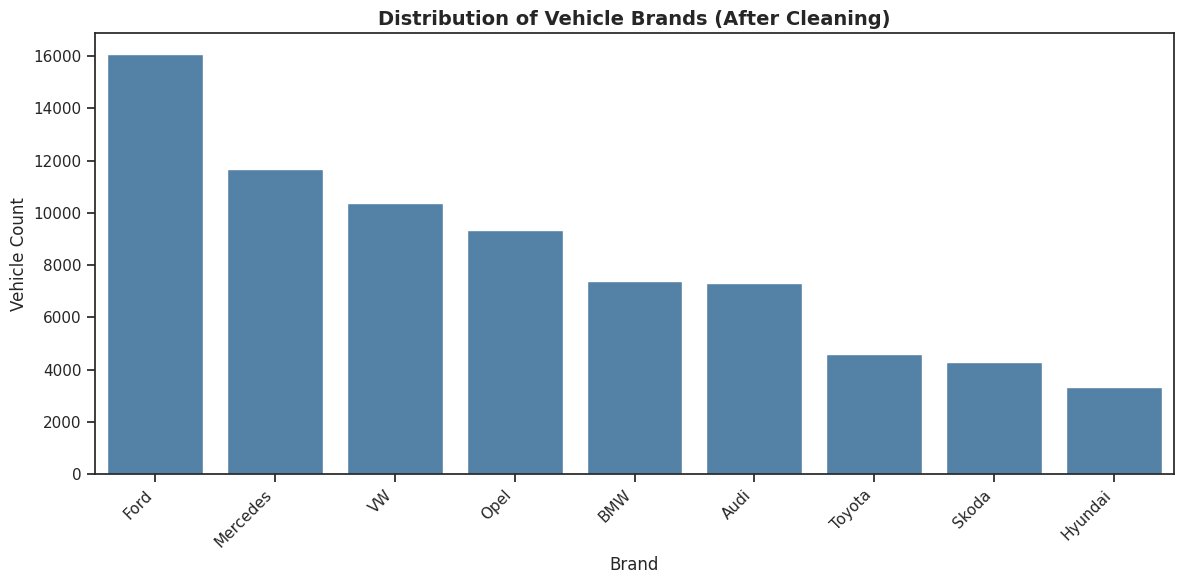

In [204]:
# =========================================
# Brand distribution after data cleaning
# =========================================

# Count vehicles per brand
brand_counts = (
    df["Brand"]
    .value_counts()
    .reset_index()
)

brand_counts.columns = ["Brand", "count"]

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(
    data=brand_counts,
    x="Brand",
    y="count",
    color="steelblue"
)

plt.title(
    "Distribution of Vehicle Brands (After Cleaning)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Vehicle Count", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## **2.2 Model Feature Exploration and Cleaning**

In [205]:
df["model"].unique()

array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

In [206]:
len(df["model"].unique())

736

In [207]:
# group models by brand
grouped = df.groupby("Brand")["model"].value_counts()

display(grouped["Hyundai"])

,count
model,
Tucson,821
I10,671
I30,352
I20,307
Kona,213
Ioniq,185
Santa Fe,135
IX20,129
I40,78


In [208]:
#we obtained all the correct model names by feeding all possible variations for each brand into ChatGPT and creating a dictionary with the correct model names
# Obtained through meticulous ChatGPT prompt engineering

valid_models = {
    "Audi": [
        "A1", "A2", "A3", "A4", "A5", "A6", "A7", "A8",
        "Q2", "Q3", "Q5", "Q7", "Q8",
        "TT", "R8",
        "S3", "S4", "S5", "S8",
        "RS3", "RS4", "RS5", "RS6",
        "SQ5", "SQ7"
    ],

    "Ford": [
        "FOCUS", "FIESTA", "MONDEO", "KA", "KA+", "FUSION",
        "KUGA", "ECOSPORT", "EDGE", "PUMA",
        "CMAX", "BMAX", "SMAX", "GALAXY",
        "GRANDCMAX", "TOURNEOCONNECT", "GRANDTOURNEOCONNECT", "TOURNEOCUSTOM",
        "MUSTANG", "RANGER", "ESCORT", "STREETKA"
    ],

    "Mercedes": [
        "ACLASS", "BCLASS", "CCLASS", "ECLASS", "SCLASS",
        "GLA", "GLB", "GLC", "GLE", "GLS", "GCLASS", "GLCLASS", "MCLASS",
        "CLA", "CLS", "SL", "SLK", "CLK",
        "VCLASS", "XCLASS", "CLC"
    ],

    "VW": [
        "GOLF", "POLO", "PASSAT", "JETTA", "ARTEON", "SCIROCCO", "BEETLE",
        "UP", "GOL", "FOX",
        "TIGUAN", "TIGUANALLSPACE", "TROC", "TCROSS", "TOUAREG",
        "TOURAN", "SHARAN", "CADDY", "CADDYMAXI", "CADDYMAXILIFE",
        "CARAVELLE", "CALIFORNIA", "SHUTTLE",
        "AMAROK", "GOLFSV"
    ],

    "Opel": [
        "CORSA", "ASTRA", "INSIGNIA", "VECTRA",
        "MOKKA", "MOKKAX", "CROSSLAND", "CROSSLANDX",
        "GRANDLAND", "GRANDLANDX", "ANTARA",
        "ZAFIRA", "ZAFIRATOURER", "MERIVA", "COMBOLIFE", "VIVARO",
        "ADAM", "AGILA", "VIVA",
        "TIGRA", "GTC", "CASCADA", "AMPERA"
    ],

    "BMW": [
        "1SERIES", "2SERIES", "3SERIES", "4SERIES",
        "5SERIES", "6SERIES", "7SERIES", "8SERIES",
        "X1", "X2", "X3", "X4", "X5", "X6", "X7",
        "M2", "M3", "M4", "M5", "M6",
        "Z3", "Z4",
        "I3", "I4", "I8"
    ],

    "Toyota": [
        "YARIS", "AYGO", "AURIS", "COROLLA", "AVENSIS", "CAMRY", "PRIUS",
        "CHR", "RAV4", "LANDCRUISER", "URBANCRUISER",
        "VERSO", "VERSOS", "PROACEVERSO",
        "HILUX", "GT86", "SUPRA", "IQ"
    ],

    "Skoda": [
        "FABIA", "OCTAVIA", "SUPERB", "RAPID", "SCALA",
        "KODIAQ", "KAROQ", "KAMIQ", "YETI", "YETIOUTDOOR",
        "CITIGO", "ROOMSTER"
    ],

    "Hyundai": [
        "I10", "I20", "I30", "I40", "ACCENT", "GETZ",
        "KONA", "TUCSON", "SANTAFE", "IX20", "IX35",
        "I800", "IONIQ", "VELOSTER", "TERRACAN"
    ]
}



We are now left with a dictionary with valid brand names and their corresponding valid model names. Let's perform a similar treatment to the one applied to **Brand** to standardize entries for **model**.

In [209]:
def HELPER_normalize_models(df):
    df = df.copy()

    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)       # remove hyphens
        .str.replace(r"\s+", "", regex=True)     # remove all whitespace
        .replace(["", "NAN", "NONE"], None)
    )
    return df

def HELPER_hybrid_scorer(a, b, **kwargs):
    #hibrido entre o método tokenizer e o levenshtein
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100

def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand:
        return model

    # Skip unknown brands
    if brand not in valid_models_dict:
        return model

    valid_list = valid_models_dict[brand]

    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model

    model_name, score, _ = result
    return model_name if score >= threshold else None

def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)

    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(row["model"], row["Brand"], valid_models_dict, threshold),
        axis=1
    )
    return df

The first helper function normalizes all model entries into a single model.  
The second helper function used an hybrid score system to calculate similarity bettween strings.  
The final helper function acesses similarity and if the model entry is bellow a certrain threshold,we get a nan entry on model.  
Finally fuzzy_modelos, applies all the previous function to our entries.

In [210]:
len(df["model"].unique())
df[df["model"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [211]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi         62
BMW          91
Ford         92
Hyundai      52
Mercedes    103
Opel         90
Skoda        61
Toyota       68
VW          114
Name: model, dtype: int64


In [212]:
df=fuzzy_modelos(df, valid_models)
display(df[df["model"].isna()])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


In [213]:
unique_models_per_brand = df.groupby("Brand")["model"].nunique()
print(unique_models_per_brand)

Brand
Audi        25
BMW         24
Ford        22
Hyundai     15
Mercedes    13
Opel        23
Skoda       12
Toyota      18
VW          25
Name: model, dtype: int64


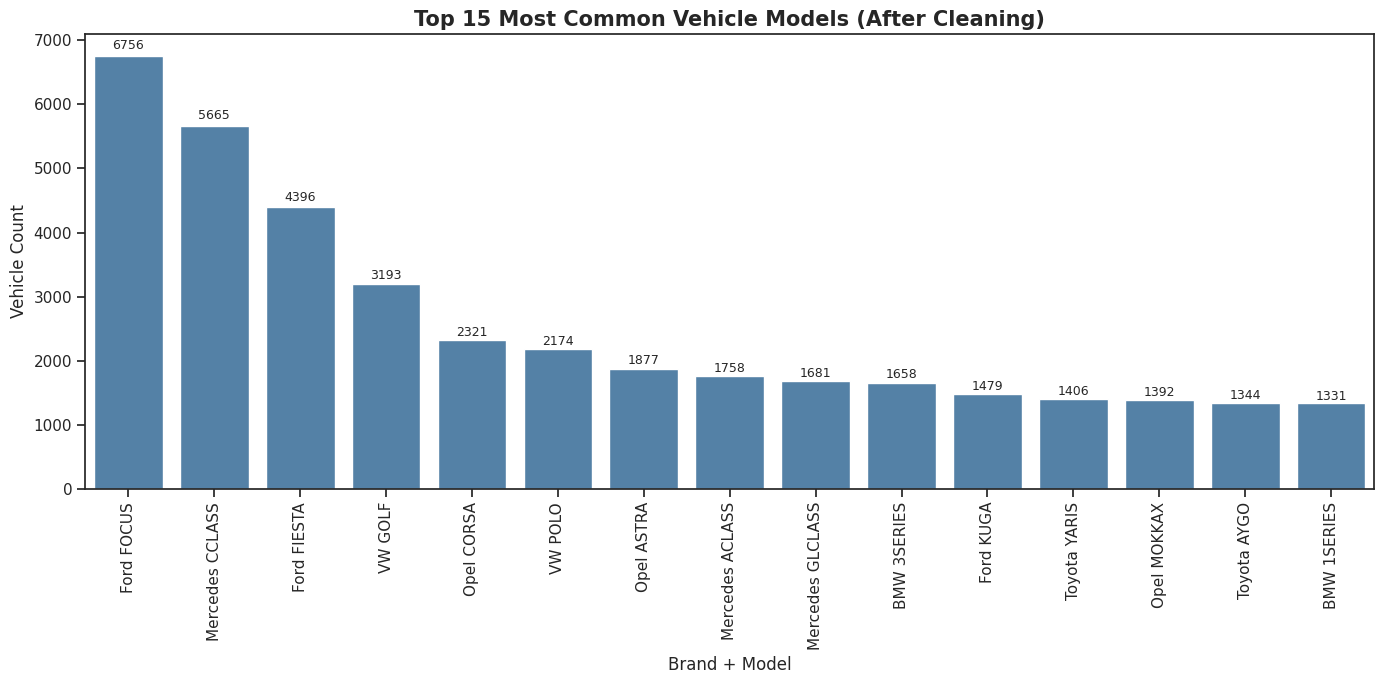

In [214]:
# =========================================
# Top N most common vehicle models (Brand + Model)
# =========================================

top_n = 15  # adjust if needed

# Create Brand + Model label
df_plot = df.copy()
df_plot["Brand_Model"] = df_plot["Brand"] + " " + df_plot["model"]

# Count occurrences
top_models = (
    df_plot["Brand_Model"]
    .value_counts()
    .head(top_n)
    .reset_index()
)

top_models.columns = ["Brand_Model", "vehicle_count"]

# --- Plot setup ---
plt.figure(figsize=(14, 7))
sns.barplot(
    data=top_models,
    x="Brand_Model",
    y="vehicle_count",
    color="steelblue"
)

# --- Titles and formatting ---
plt.title(
    f"Top {top_n} Most Common Vehicle Models (After Cleaning)",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Brand + Model", fontsize=12)
plt.ylabel("Vehicle Count", fontsize=12)
plt.xticks(rotation=90, ha="center")

# --- Add plain number labels above bars ---
for i, val in enumerate(top_models["vehicle_count"]):
    plt.text(
        i,
        val + val * 0.01,
        str(int(val)),
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()


## **2.3 Year analysis and cleaning**

In [215]:
df["year"].unique()

array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

In [216]:
old_cars = df[df["year"] < 2000][["Brand", "model", "year","engineSize"]]
display(old_cars)

,Brand,model,year,engineSize
carID,,,,
25881,Ford,ESCORT,1996.0,1.8
3908,Audi,A3,1998.0,1.8
62732,Opel,ZAFIRA,1970.0,NaN
13422,BMW,Z3,1999.0,1.9
36128,Mercedes,SLK,1998.0,2.3
51800,Toyota,YARIS,1999.0,1.3
34918,Mercedes,SCLASS,1997.0,3.2
52914,Toyota,LANDCRUISER,1998.0,4.2
35769,Mercedes,MCLASS,1970.0,0.0


In [217]:
#feature enginering year
def limpar_anos(df,max_year=2020):
    df = df.copy()

    df["year"] = max_year - df["year"]
    df.loc[(df["year"] < 0) | (df["year"] > 50), "year"] = np.nan #os carros de 1970 nem existiam em 1970 e os dados são referentes a 2020 carros depois disso não são válidos
    df["year"] = np.floor(df["year"]).astype("Int64")
    return df

We transformed years feature , instead of being the release date of the car , we will instead treat this feature as the age.  
We will also assume that entries that are negative years old , are a typo.  
We also discovered that car entries from before 1980 were also typos, this could be due to the fact that many computer that use UNIX system start time at 1970 , so most likely this costumer didn't enter any year and the sistem assigned it.

In [218]:
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,NaN,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
68423,VW,POLO,NaN,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,NaN,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,NaN,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
37812,Mercedes,ECLASS,NaN,17165,Automatic,36959.0,Diesel,150.000000,53.3,3.0,53.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,NaN,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,NaN,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,NaN,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


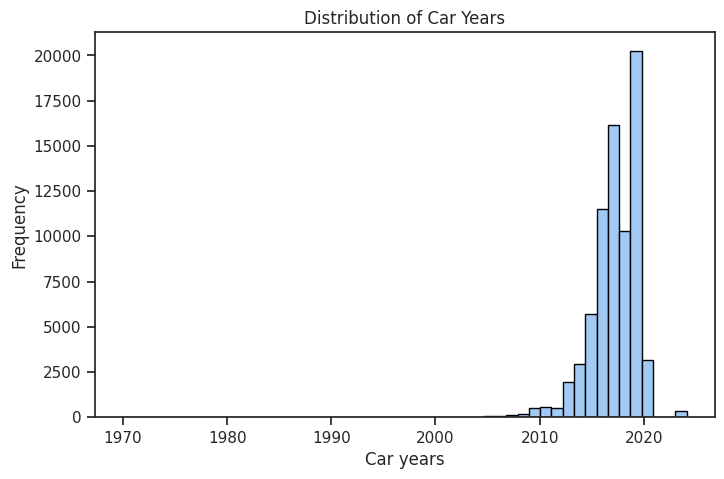

In [219]:
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Years")
plt.xlabel("Car years")
plt.ylabel("Frequency")
plt.show()

In [220]:
df = limpar_anos(df,2020)
df[df["year"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


In [221]:
df["year"].unique()

<IntegerArray>
[   4,    1,    2,    6,    3,    0,    7, <NA>,    5,    9,    8,   17,   11,
   13,   15,   16,   10,   12,   14,   19,   20,   18,   24,   22,   50,   21,
   23]
Length: 27, dtype: Int64

In [222]:
ordenado = df.sort_values("price", ascending=True)

baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = baratos[["Brand", "model", "year", "price"]].tail(5)
display(baratos)
display(caros)


#acho possível estes carros em especifico terem estes preços

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


## **2.4 Transmission Exploration and Cleaning**

In [223]:
df["transmission"].unique()

array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

In [224]:
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [225]:
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [226]:
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm

    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_transmissao(df, threshold=60):
    df=df.copy()
    df = HELPER_normalize_transmission(df)
    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df

If transmission entry has similarity score greater than threshold , assign it to it's neighbour otherwise  assign nan.

In [227]:
df = fuzzy_transmissao(df)
df[df["transmission"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


In [228]:
df["transmission"].unique()

array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

## **2.5 Mileage analysis and cleaning**

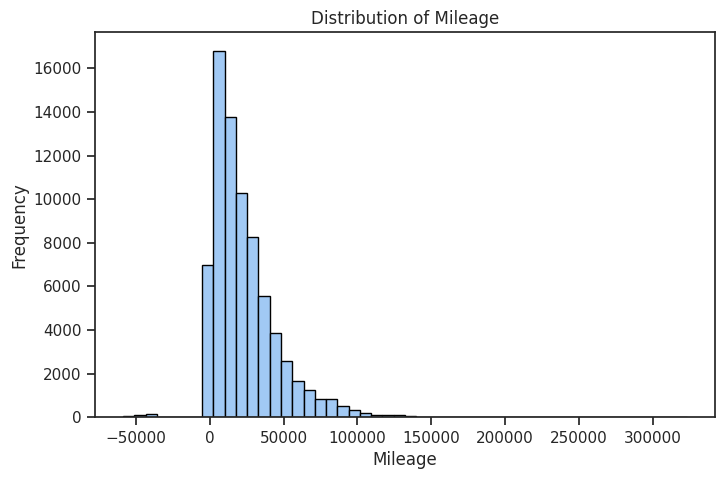

In [229]:
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

In [230]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,1,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,3,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


In [231]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,1,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,1,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,3,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,0,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,5,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


In [232]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

if milleage is lower than 0 assign np.nan

In [233]:
df=impossible_to_nan(df, "mileage")
df.loc[70615]

,70615
Brand,VW
model,TIGUAN
year,0
price,25000
transmission,MANUAL
mileage,NaN
fuelType,Petrol
tax,145.0
mpg,38.2
engineSize,1.5


In [234]:
df[df["mileage"] < 0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


In [235]:
df[df["mileage"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,4,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,1,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


## **2.6 Fuel Type analysis**

In [236]:
df["fuelType"].unique()

array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

In [237]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [238]:
df["fuelType"].value_counts()

,count
fuelType,
Petrol,37995
Diesel,28474
Hybrid,2043
PETROL,795
etrol,794
Petro,785
petrol,746
iesel,603
diesel,599


In [239]:
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df

In [240]:
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel

    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan

def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df

If fuel type entry has similarity score greater than 60 , assign it to it's neighbour otherwise  assign nan.

In [241]:
df=fuzzy_fuel(df)
df["fuelType"].unique()

array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

In [242]:
df[df["fuelType"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


In [243]:
df["fuelType"].value_counts()

,count
fuelType,
PETROL,41181
DIESEL,30885
HYBRID,2225
OTHER,167
ELECTRIC,4


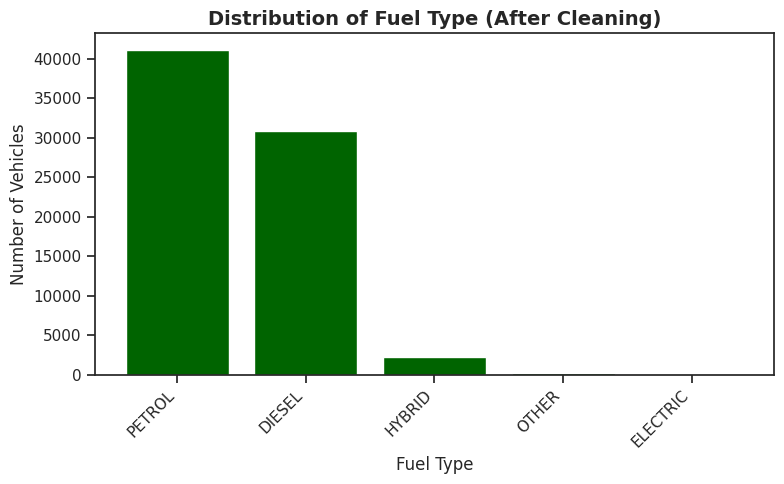

In [244]:
# =========================================
# Distribution of Fuel Type (After Cleaning)
# =========================================

# Count vehicles per fuel type
fuel_summary = (
    df["fuelType"]
    .value_counts()
    .reset_index()
)

fuel_summary.columns = ["fuelType", "vehicle_count"]

# --- Visualization ---
plt.figure(figsize=(8, 5))
plt.bar(
    fuel_summary["fuelType"].astype(str),
    fuel_summary["vehicle_count"],
    color="darkgreen"
)

plt.title(
    "Distribution of Fuel Type (After Cleaning)",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Fuel Type", fontsize=12)
plt.ylabel("Number of Vehicles", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## **2.7 Tax analysis**

In [245]:
df[df["tax"]==0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,CHR,3,15490,AUTOMATIC,59000.0,HYBRID,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,DIESEL,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,YARIS,6,10490,AUTOMATIC,34528.0,HYBRID,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,RAPID,4,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,FIESTA,7,6500,MANUAL,43181.0,PETROL,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,AYGO,3,6620,MANUAL,10266.0,PETROL,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,AYGO,4,8550,MANUAL,20680.0,PETROL,0.0,69.0,1.0,66.0,2.0,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


In [246]:
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df=df.copy()

    if lower_upper=="lower":
        df.loc[df[col]<val, col] = np.nan
        return df
    else:
        df.loc[df[col]>val, col] = np.nan
        return df

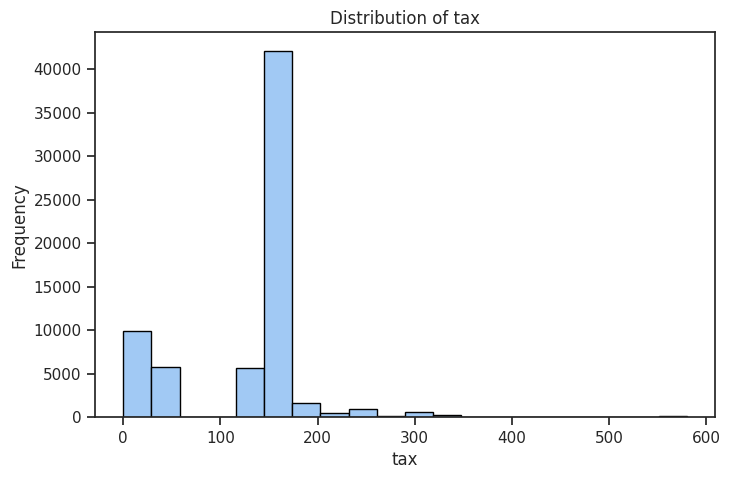

In [247]:
df=impossible_to_nan(df, "tax")

plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of tax")
plt.xlabel("tax")
plt.ylabel("Frequency")
plt.show()

There's no negative values for the UK's road tax , as such we will assign np.nan to all null taxes.

In [248]:
g = df[df["tax"] == 0]
g["year"].value_counts()

,count
year,
4,1675
3,1046
5,827
6,391
7,221
8,29
9,20
10,8
11,5


## **2.8 mpg analysis**

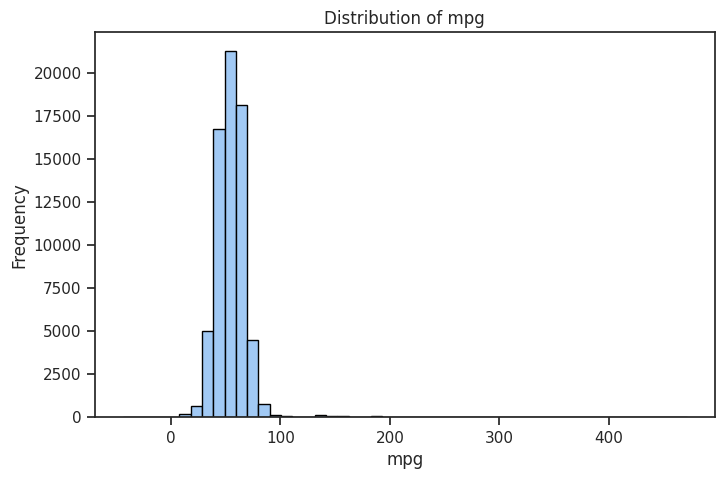

In [249]:
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

There's no negative mpg , as such we will assign all negative values to np.nan.

In [250]:
df[df["mpg"]>=100]["fuelType"].value_counts()

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


In [251]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


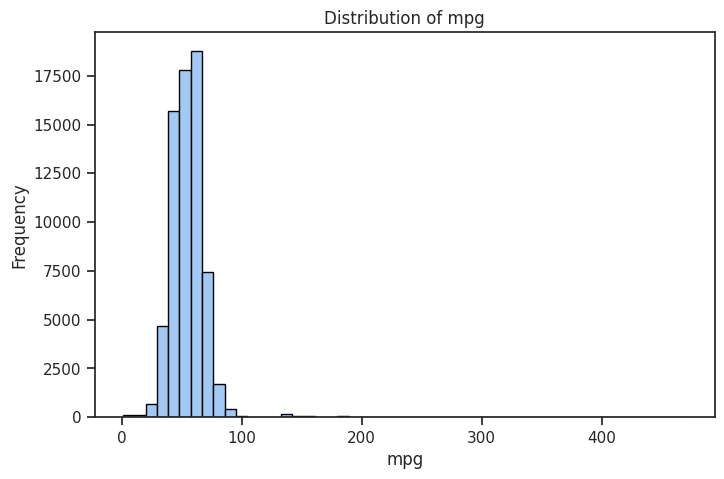

In [252]:
df=impossible_to_nan(df, "mpg")

plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of mpg")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

In [253]:
df[df["mpg"]>=100]["fuelType"].value_counts()

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


In [254]:
df[df["mpg"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


## **2.9 Engine size analysis**

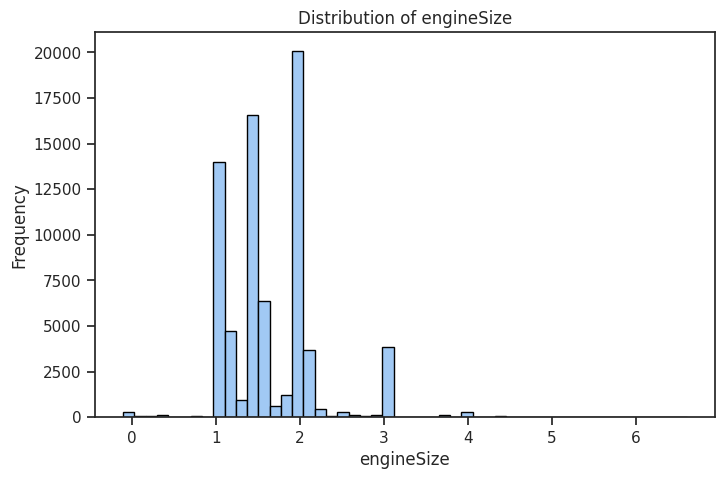

In [255]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

In [256]:
df[df["engineSize"] <1]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,0.739534,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,1,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46732,Skoda,OCTAVIA,2,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,4,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0
59040,Opel,GRANDLANDX,1,17289,MANUAL,14421.0,DIESEL,145.0,56.5,0.739534,74.0,0.0,0.0


In [257]:
df[df["engineSize"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,NaN,GOLF,4,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,1,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,3,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


In [258]:
df[df["engineSize"]>6]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,CCLASS,7,23000,SEMI-AUTO,43442.000000,PETROL,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,CCLASS,7,22995,SEMI-AUTO,49964.000000,PETROL,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7SERIES,3,57000,AUTOMATIC,11297.000000,PETROL,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,CCLASS,6,26998,SEMI-AUTO,24175.000000,PETROL,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,CCLASS,6,28990,SEMI-AUTO,19562.000000,PETROL,NaN,NaN,6.2,83.0,0.0,0.0
39852,Mercedes,SCLASS,10,26990,AUTOMATIC,38000.000000,PETROL,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,CCLASS,7,23990,AUTOMATIC,NaN,PETROL,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,CCLASS,6,25885,SEMI-AUTO,86705.854885,PETROL,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,CCLASS,<NA>,22995,SEMI-AUTO,49964.000000,PETROL,326.028233,NaN,6.2,58.0,3.0,0.0


In [259]:
df=impossible_to_nan(df, "engineSize", 1)
df[df["engineSize"].isna()]


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,NaN,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,5,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,0,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


The lowest EngineSize that can be reasonably be expected is 0.6-1 , so we will define this as the floor ,as any values lower than this is most likely a missinput.

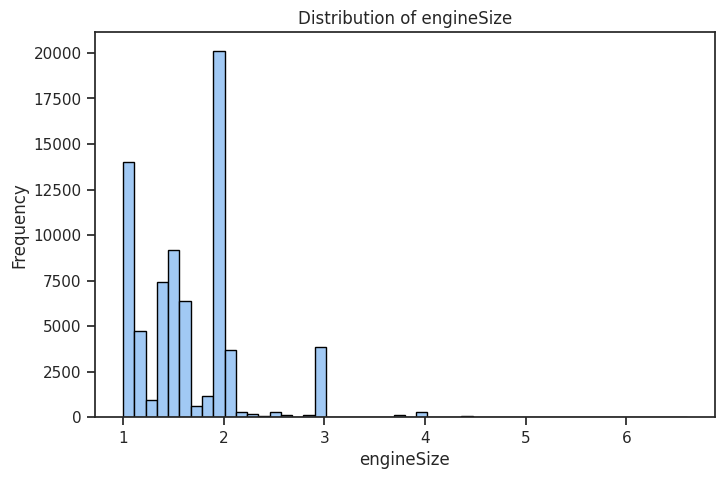

In [260]:
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of engineSize")
plt.xlabel("engineSize")
plt.ylabel("Frequency")
plt.show()

## **2.10 paintQuality analysis**

In [261]:
def drop_paint(df):
    df = df.copy()
    df = df.drop(columns=["paintQuality%"], errors="ignore")
    return df


In [262]:
df=drop_paint(df)

We will drop paintQuality due to our  assignment's instructions, as our model should only accept features that don't require a customer to see a mechanic.

## **2.11 previous Owners analysis**

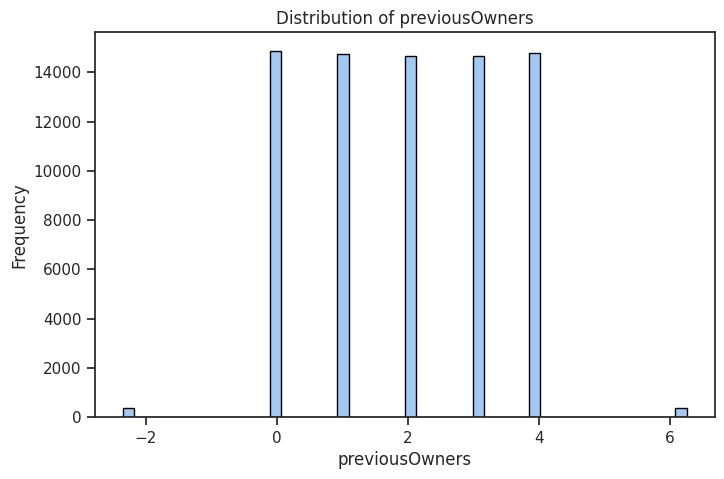

In [263]:
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of previousOwners")
plt.xlabel("previousOwners")
plt.ylabel("Frequency")
plt.show()

In [264]:
df["previousOwners"].unique()

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

In [265]:
df[df["previousOwners"]<0]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,-2.340306,0.0
71677,VW,TIGUAN,1,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,-2.345650,0.0
16962,Ford,FOCUS,1,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,-2.340306,0.0
5994,Audi,None,0,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,-2.335123,0.0
5038,Audi,RS6,0,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,0,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,-2.345650,0.0
75599,VW,UP,5,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,-2.345650,0.0
28295,Ford,SMAX,3,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,-2.340306,0.0


In [266]:
df[df["previousOwners"].isna()]

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,NaN,0.0
18304,Ford,None,4,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,NaN,0.0
49135,Skoda,SCALA,0,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,NaN,0.0
37446,Mercedes,CCLASS,1,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,NaN,0.0
1768,Audi,Q3,0,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,6,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,NaN,0.0
6295,Audi,A3,2,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,NaN,0.0
21918,Ford,FIESTA,1,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,NaN,0.0


In [267]:
def round_owners_int(df):
    df=df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")

    df['previousOwners'] = df['previousOwners'].round().astype('Int64')
    return df

In [268]:
df=impossible_to_nan(df,"previousOwners")
df=round_owners_int(df)
df["previousOwners"].unique()

<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

Obviously negative ammount of owners make no sense so will assign them no nan.

## **2.12 hasDamage analysis**

In [269]:
df["hasDamage"].unique() #está cheia de zeros

array([ 0., nan])

In [270]:
def remove_hasdmg(df):
    df = df.copy()
    df = df.drop(columns=["hasDamage"], errors="ignore")
    return df

In [271]:
df=remove_hasdmg(df)
display(df)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3
...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,0
6265,Audi,Q3,7,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,2
54886,Toyota,AYGO,3,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,3


This feature has no value due to the fact that they have only 1 values, which makes it useless for training.

In [272]:
missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': (missing / len(df)) * 100
})

print("Missing Values with Percentage:\n")
print(missing_df)



Missing Values with Percentage:

                Missing Count  Missing Percentage
tax                      8282           10.901241
mpg                      7962           10.480039
engineSize               2090            2.750977
previousOwners           1921            2.528530
year                     1849            2.433759
mileage                  1832            2.411383
model                    1578            2.077054
transmission             1522            2.003343
Brand                    1521            2.002027
fuelType                 1511            1.988864
price                       0            0.000000


In [273]:
def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna('UNKNOWN')

    return df

## **2.13 feature engineering**

In [274]:
def mileage_per_year(df):
    age_divisor = np.maximum(df['year'],1)
    df["mileage_per_year"] = df["mileage"] / age_divisor
    return df

In [275]:
def power_efficiency(df):
    df["power_efficiency"] = df["engineSize"] / (df["mpg"])
    max_finite = df.loc[np.isfinite(df["power_efficiency"]), "power_efficiency"].max()
    df["power_efficiency"] = df["power_efficiency"].replace([np.inf], max_finite)

    return df

In [276]:
df=mileage_per_year(df)
df=power_efficiency(df)

2 new features that will hopefully help us get us a better price prediction.

## **2.14 Price analysis**

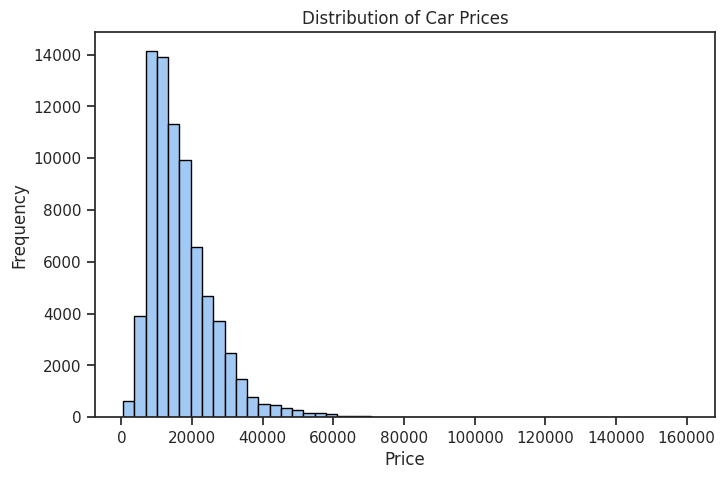

In [277]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [278]:
df["price"].describe()

,price
count,75973.000000
mean,16881.889553
std,9736.926322
min,450.000000
25%,10200.000000
50%,14699.000000
75%,20950.000000
max,159999.000000


To handle the right skew preemptively a log transform may be needed, we cant apply a Yeo-Johnson a priori because that would be data leakage, a log transform is deterministic

/tmp/ipython-input-3589495806.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




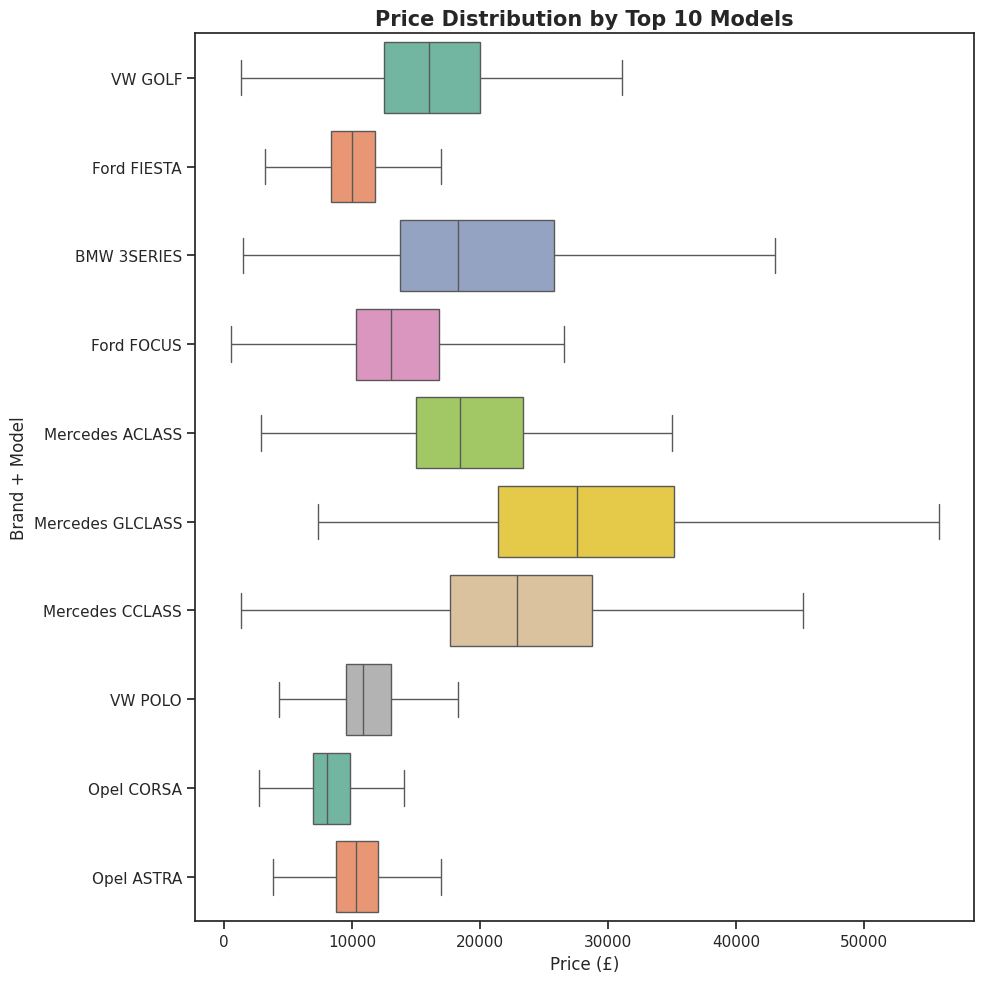

/tmp/ipython-input-3589495806.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




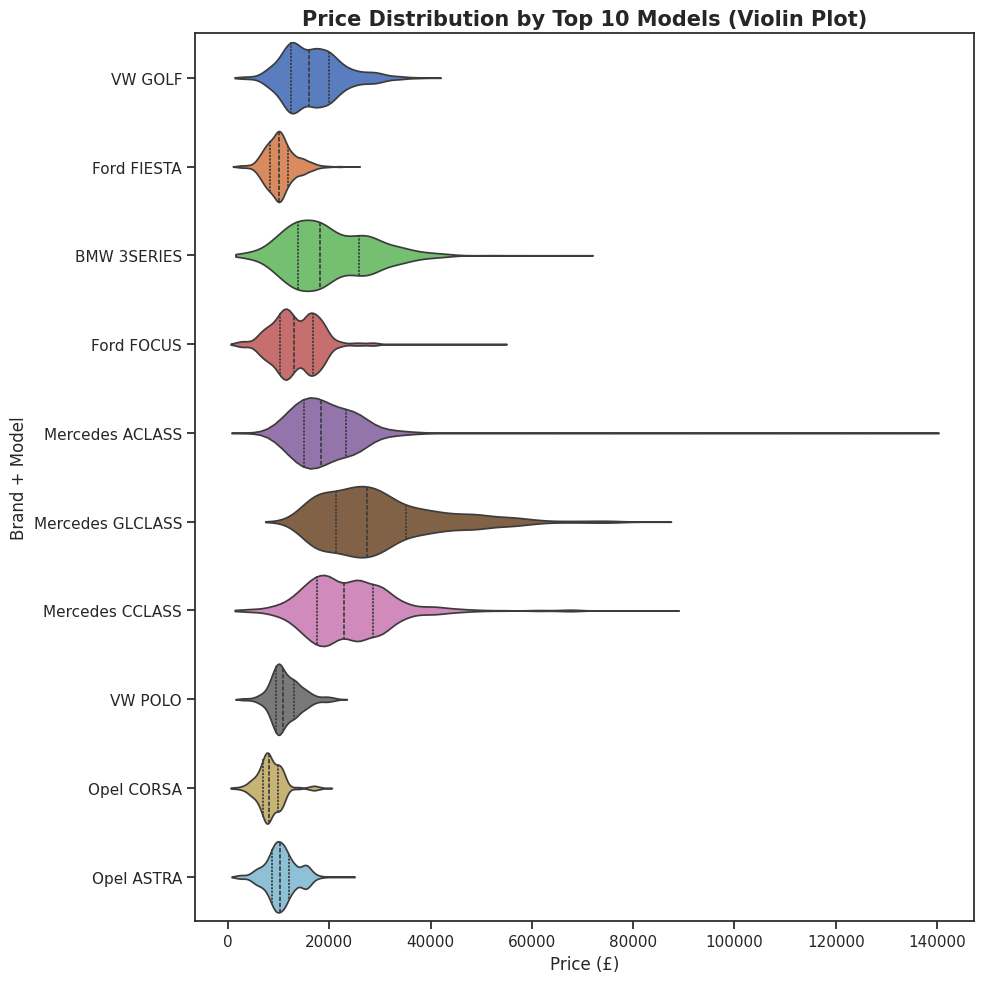

In [279]:
# =========================================
# Price distribution by top N models
# =========================================

top_n_models = 10  # adjust if needed

# Create Brand + Model label (EDA only)
df_plot = df.copy()
df_plot["brand_model"] = df_plot["Brand"] + " " + df_plot["model"]

# Select top N most frequent models
top_models = (
    df_plot["brand_model"]
    .value_counts()
    .head(top_n_models)
    .index
)

filtered_df = df_plot[df_plot["brand_model"].isin(top_models)]

# --- Boxplot ---
plt.figure(figsize=(10, 10))
sns.boxplot(
    data=filtered_df,
    y="brand_model",
    x="price",
    palette="Set2",
    showfliers=False  # hide extreme outliers for readability
)

plt.title(
    f"Price Distribution by Top {top_n_models} Models",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Price (£)", fontsize=12)
plt.ylabel("Brand + Model", fontsize=12)
plt.tight_layout()
plt.show()

# --- Optional: Violin plot for smoother distribution ---
plt.figure(figsize=(10, 10))
sns.violinplot(
    data=filtered_df,
    y="brand_model",
    x="price",
    palette="muted",
    inner="quartile",
    cut=0
)

plt.title(
    f"Price Distribution by Top {top_n_models} Models (Violin Plot)",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Price (£)", fontsize=12)
plt.ylabel("Brand + Model", fontsize=12)
plt.tight_layout()
plt.show()


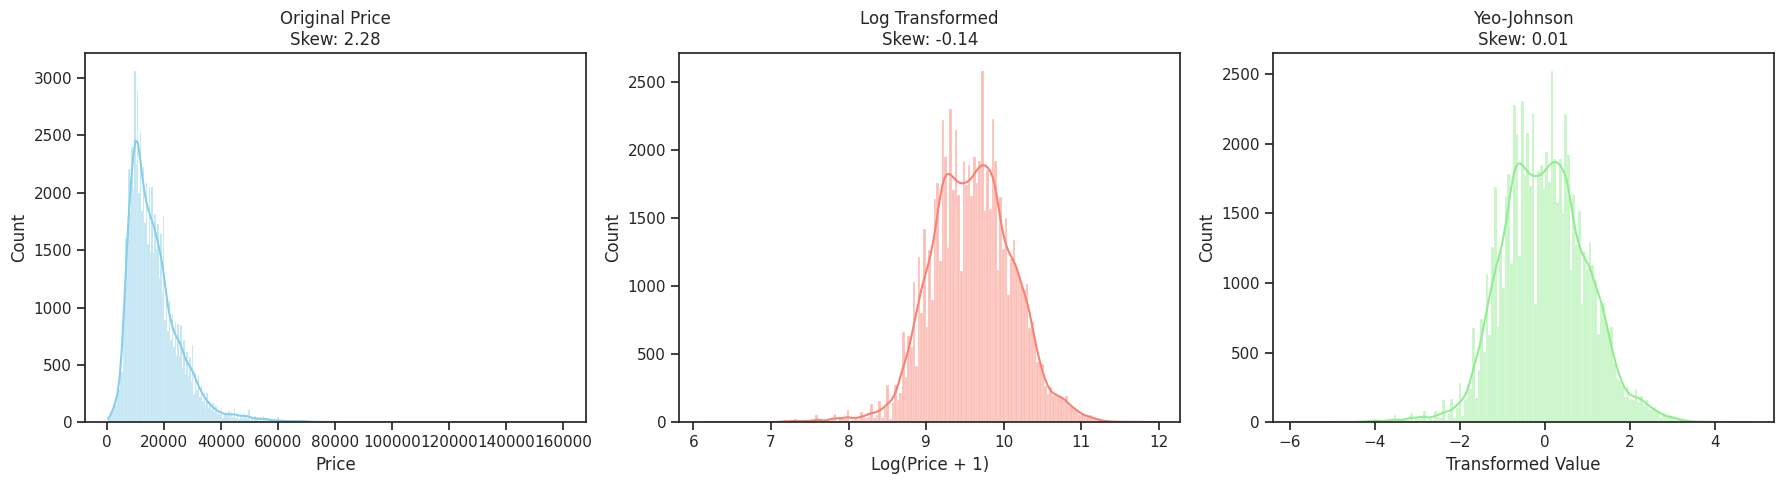

In [280]:
y = df["price"]
y_log = np.log1p(y)
# Yeo-Johnson Transformation (standardizes and removes skew)
pt = PowerTransformer(method='yeo-johnson')
y_yj = pt.fit_transform(y.values.reshape(-1, 1)).flatten()

# 2. Setup the visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original Price
sns.histplot(y, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title(f"Original Price\nSkew: {y.skew():.2f}")
axes[0].set_xlabel("Price")

# Plot 2: Log Transformation
sns.histplot(y_log, kde=True, ax=axes[1], color='salmon')
axes[1].set_title(f"Log Transformed\nSkew: {pd.Series(y_log).skew():.2f}")
axes[1].set_xlabel("Log(Price + 1)")

# Plot 3: Yeo-Johnson Transformation
sns.histplot(y_yj, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title(f"Yeo-Johnson\nSkew: {pd.Series(y_yj).skew():.2f}")
axes[2].set_xlabel("Transformed Value")

plt.tight_layout()
plt.show()

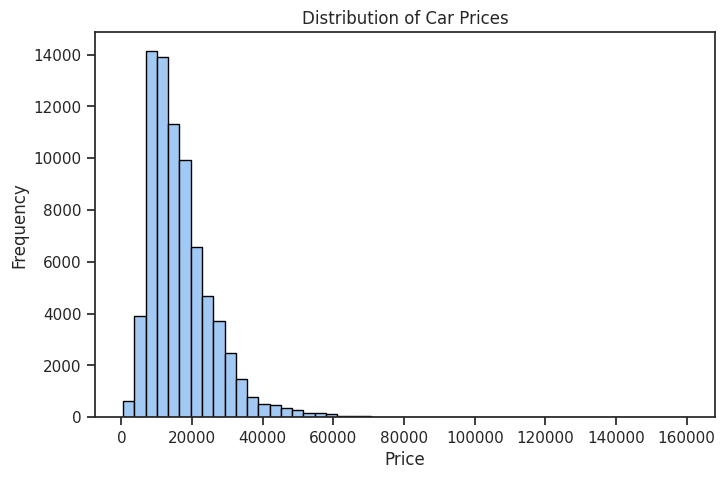

In [281]:

plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

## **2.15 Bivariate analysis**


🔹 Numerical Features Selected (9):
['year', 'mileage', 'mileage_per_year', 'tax', 'mpg', 'engineSize', 'power_efficiency', 'previousOwners', 'price']


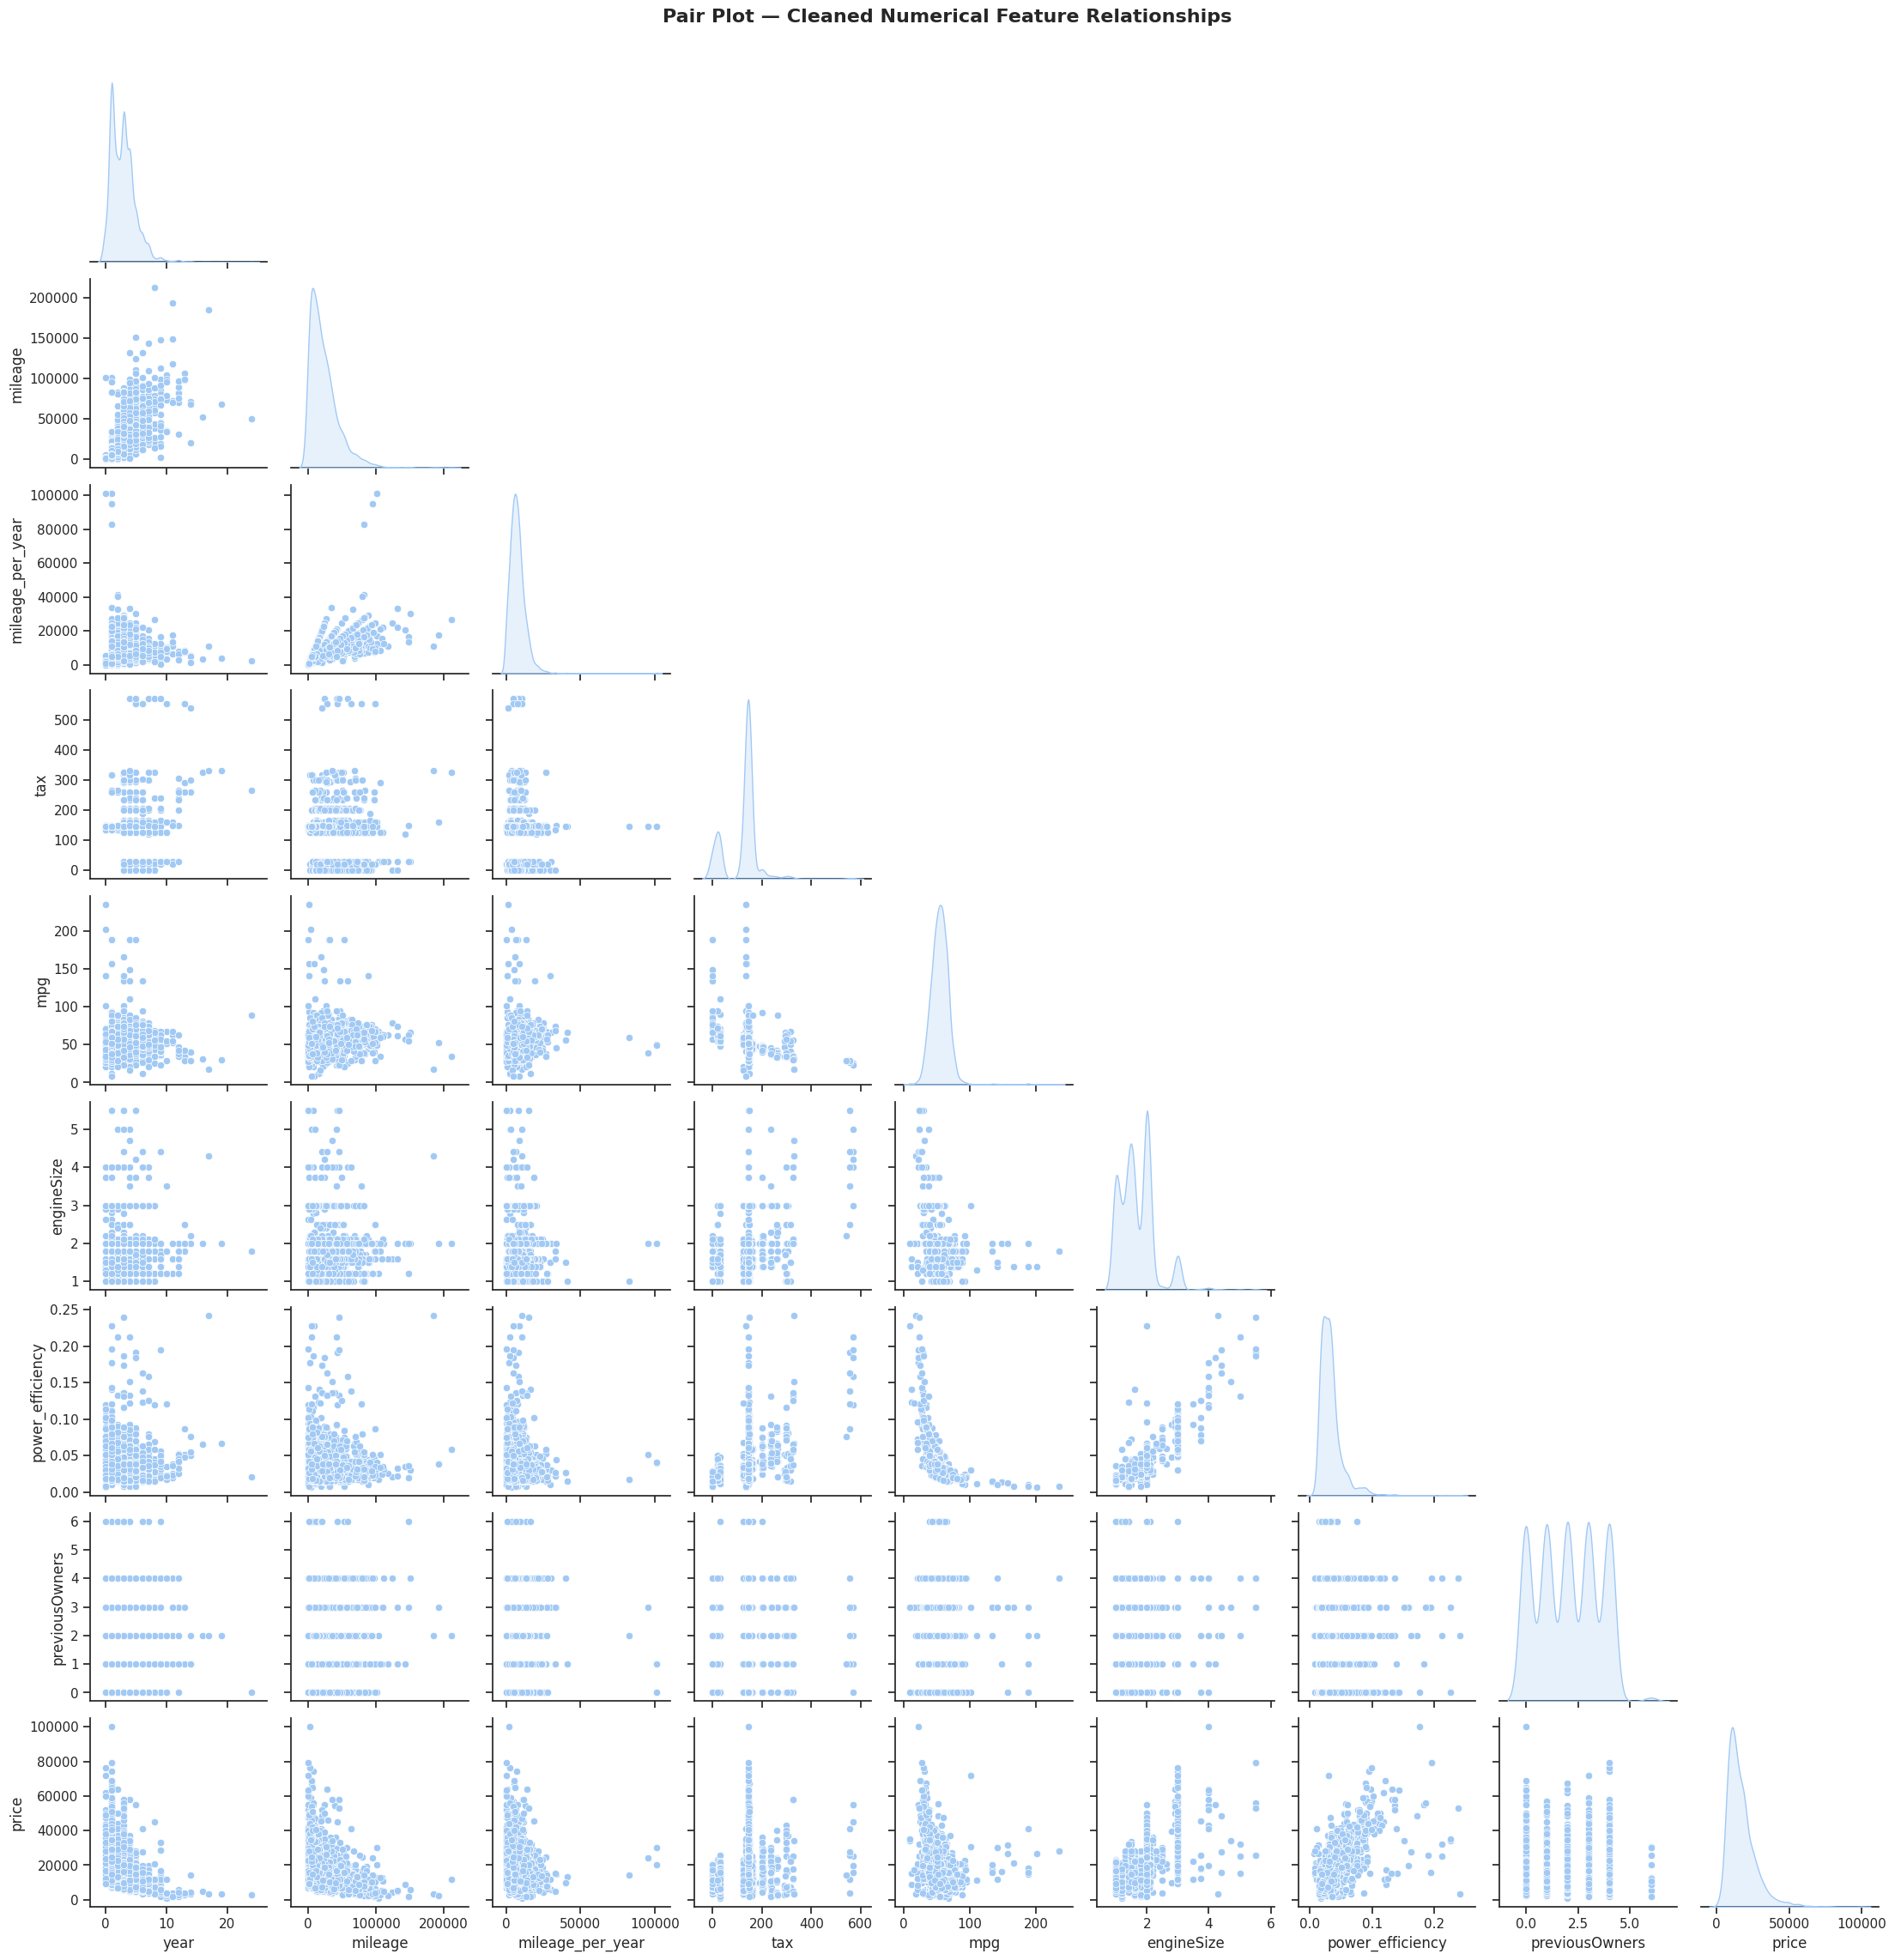

In [282]:
# -----------------------------------------------------
#  Pair Plot — Cleaned Numerical Features (Cars4You)
# -----------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt

# --- Step 1: Safety check ---
if "df" not in locals():
    raise ValueError("❌ DataFrame 'df' not found. Please load and clean the data first.")

# --- Step 2: Select numerical features used in the pipeline ---
numeric_features = [
    "year",
    "mileage",
    "mileage_per_year",
    "tax",
    "mpg",
    "engineSize",
    "power_efficiency",
    "previousOwners",
    "price"   # include target only for EDA
]

# Keep only existing columns (robust to TOY / partial datasets)
numeric_features = [col for col in numeric_features if col in df.columns]

print(f"\n🔹 Numerical Features Selected ({len(numeric_features)}):")
print(numeric_features)

# --- Step 3: Drop rows with missing values (EDA only) ---
pairplot_data = df[numeric_features].dropna()

# Optional: subsample to keep the plot readable
MAX_POINTS = 3000
if len(pairplot_data) > MAX_POINTS:
    pairplot_data = pairplot_data.sample(MAX_POINTS, random_state=42)

# --- Step 4: Plot configuration ---
sns.set(style="ticks", palette="pastel")

pair_plot = sns.pairplot(
    pairplot_data,
    diag_kind="kde",   # smooth density on diagonals
    corner=True        # lower triangle only
)

pair_plot.fig.suptitle(
    "Pair Plot — Cleaned Numerical Feature Relationships",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()


Observa-se uma relação forte e não linear entre preço e variáveis como year, mileage e mileage_per_year, com carros mais recentes e menos usados a apresentarem preços claramente mais elevados.

Variáveis como engineSize e power_efficiency mostram tendências positivas com o preço, mas com grande dispersão, indicando interações complexas e possível dependência de outras features.

Algumas features (previousOwners, tax) apresentam distribuições discretas e fraca correlação direta com o preço, o que explica porque modelos lineares têm dificuldade em capturar bem estas relações.

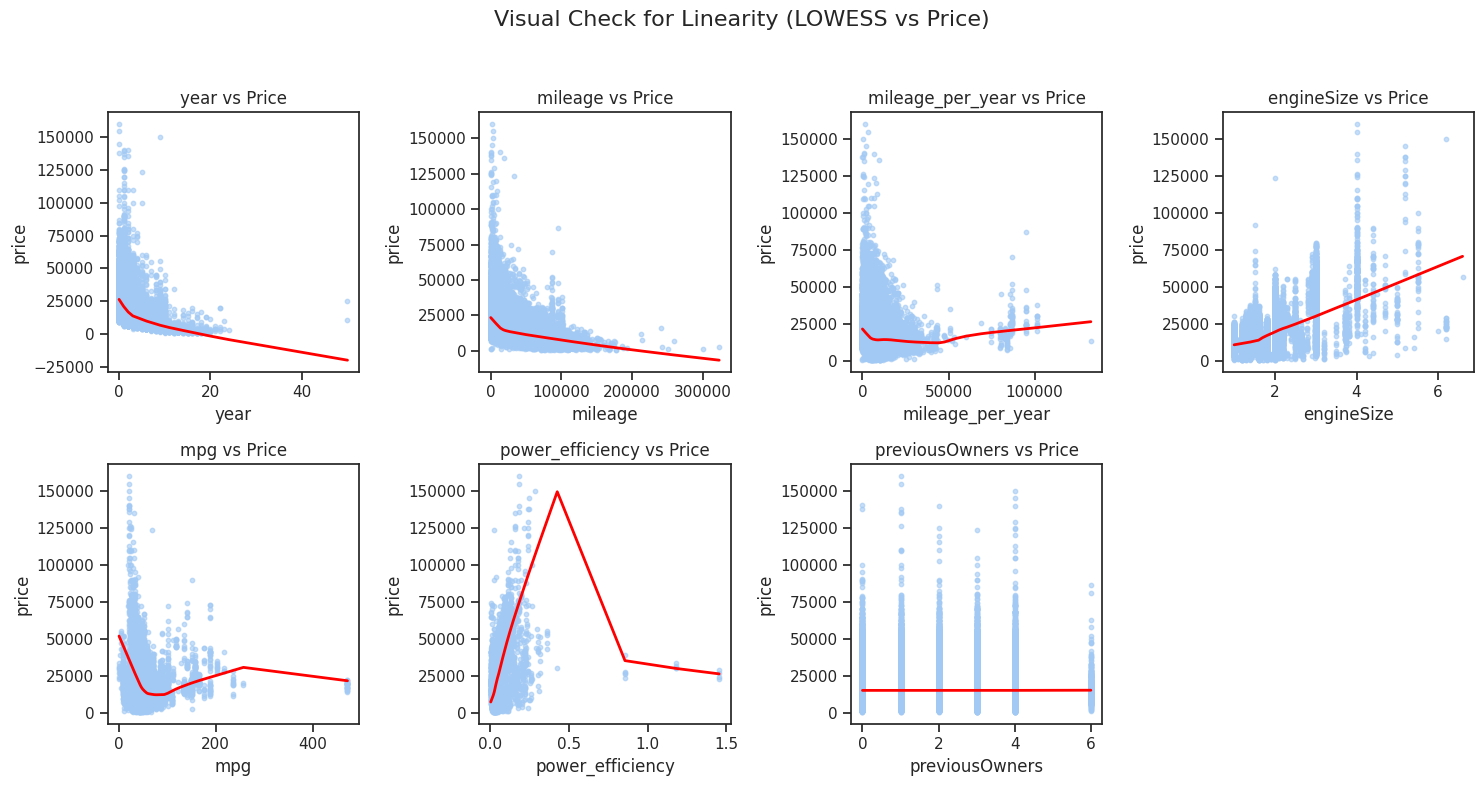

In [283]:
# -----------------------------------------------------
#  Visual check for linearity (LOWESS vs Price)
# -----------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import math

# --- Step 1: Select numerical features from the pipeline ---
numeric_features = [
    "year",
    "mileage",
    "mileage_per_year",
    "engineSize",
    "mpg",
    "power_efficiency",
    "previousOwners"
]

# Keep only features that exist (robust to TOY / partial datasets)
numeric_features = [f for f in numeric_features if f in df.columns]

# --- Step 2: Subplot layout ---
sp_rows = 2
sp_cols = math.ceil(len(numeric_features) / sp_rows)

fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(15, 8))
axes = axes.flatten()

# --- Step 3: Plot LOWESS regressions ---
for ax, feat in zip(axes, numeric_features):
    sns.regplot(
        x=df[feat],
        y=df["price"],
        lowess=True,
        ax=ax,
        scatter_kws={"s": 10, "alpha": 0.6},
        line_kws={"color": "red", "lw": 2}
    )
    ax.set_title(f"{feat} vs Price")

# Remove unused axes
for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

# --- Step 4: Final layout ---
plt.suptitle(
    "Visual Check for Linearity (LOWESS vs Price)",
    fontsize=16
)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


Em linha com a análise anterior, os gráficos LOWESS confirmam que as relações entre preço e variáveis-chave são maioritariamente não lineares, especialmente para year, mileage e mileage_per_year, o que penaliza modelos lineares simples.

Variáveis como engineSize e power_efficiency apresentam tendências globais positivas, mas com mudanças de regime e elevada dispersão, sugerindo interações e efeitos marginais dependentes do contexto.

previousOwners mostra um comportamento praticamente plano em relação ao preço, reforçando que o seu contributo isolado é fraco e que o seu impacto só é captado eficazmente por modelos capazes de lidar com não linearidades e interações.

## **2.16 Data Cleaning and Standardization Pipeline**

In [284]:

num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize','previousOwners',"mileage_per_year","power_efficiency"]
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize',"mileage_per_year","power_efficiency"]

In [285]:
df=fill_cats_UNKNOWN(df, cat_cols)

In [286]:
def clean_df(df, valid_models, cat_cols):
    df = df.copy()

    df = carID_como_index(df)
    df = fuzzy_marcas(df)
    df = fuzzy_modelos(df, valid_models)
    df = limpar_anos(df)
    df = fuzzy_transmissao(df)

    df = impossible_to_nan(df, "mileage")
    df = mileage_per_year(df)

    df = fuzzy_fuel(df)
    df = impossible_to_nan(df, "tax")
    df = impossible_to_nan(df, "mpg")
    df = impossible_to_nan(df, "engineSize", 1)

    df = power_efficiency(df)

    df = drop_paint(df)
    df = impossible_to_nan(df, "previousOwners")
    df = round_owners_int(df)

    df = remove_hasdmg(df)
    df = fill_cats_UNKNOWN(df, cat_cols)

    return df

In [287]:
og_df=clean_df(og_df, valid_models, cat_cols)

In [288]:
assert pd.testing.assert_frame_equal(df, og_df) is None
og_df

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1,4589.0,0.031315
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4,3624.0,0.036675
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,13498,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,0,2896.0,0.037523
6265,Audi,Q3,7,12495,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,8399,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,3,3768.0,0.014925


acess that all function were applied the same way as in clean_df.

Separate **price** from **df**

# **3. DATA SPLIT & PREPROCESSING PIPELINE**



## **3.1 Pipeline Strategy**

This preprocessing pipeline was designed to strictly prevent data leakage and
to mirror a real-world deployment scenario. All statistics required for data
transformation (imputation values, outlier thresholds, scaling parameters) are
learned exclusively from the training set and then reused unchanged on the
validation data.

The pipeline follows a clear and reproducible order:
1. Feature–target separation
2. Train–validation split
3. Training-based preprocessing (imputation, outlier handling, scaling)
4. Consistent application of learned transformations to unseen data

This approach ensures fair model evaluation and reliable generalisation
performance.

All exploratory plots are generated exclusively from the training set to avoid
any influence from unseen validation data.



## **3.2 Feature–Target Separation**

In [289]:
def separar_y(df):
    df=df.copy()

    X = df.drop('price', axis = 1)
    y = df['price']

    return X, y

In [290]:
X, y = separar_y(df)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,3,3768.0,0.014925


In [291]:
y

,price
carID,
69512,22290
53000,13790
6366,24990
29021,12500
10062,22995
...,...
37194,13498
6265,12495
54886,8399


## **3.3 Train–Validation Split**

In [292]:
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

X_train = X_train_raw.copy()
X_val   = X_val_raw.copy()
y_train = y_train_raw.copy()
y_val   = y_val_raw.copy()
X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
39423,Mercedes,ACLASS,1,SEMI-AUTO,3915.0,PETROL,145.0,47.9,1.3,2,3915.0,0.027140
9016,BMW,5SERIES,1,SEMI-AUTO,5687.0,HYBRID,135.0,156.9,2.0,3,5687.0,0.012747
24121,Ford,FIESTA,0,MANUAL,10.0,PETROL,145.0,56.5,1.0,0,10.0,0.017699
57460,Opel,MOKKAX,2,MANUAL,21600.0,UNKNOWN,145.0,39.2,1.4,0,10800.0,0.035714
1936,Audi,RS4,0,SEMI-AUTO,3000.0,PETROL,145.0,29.1,2.9,1,3000.0,0.099656
...,...,...,...,...,...,...,...,...,...,...,...,...
33819,Hyundai,I30,3,AUTOMATIC,19367.0,PETROL,NaN,51.4,1.4,4,6455.666667,0.027237
46982,Skoda,KAROQ,1,MANUAL,100.0,DIESEL,145.0,42.8,2.0,2,100.0,0.046729
71103,VW,UP,5,MANUAL,48429.0,PETROL,20.0,62.8,1.0,1,9685.8,0.015924


## **3.4 Missing Value Imputation (Numerical Features)**

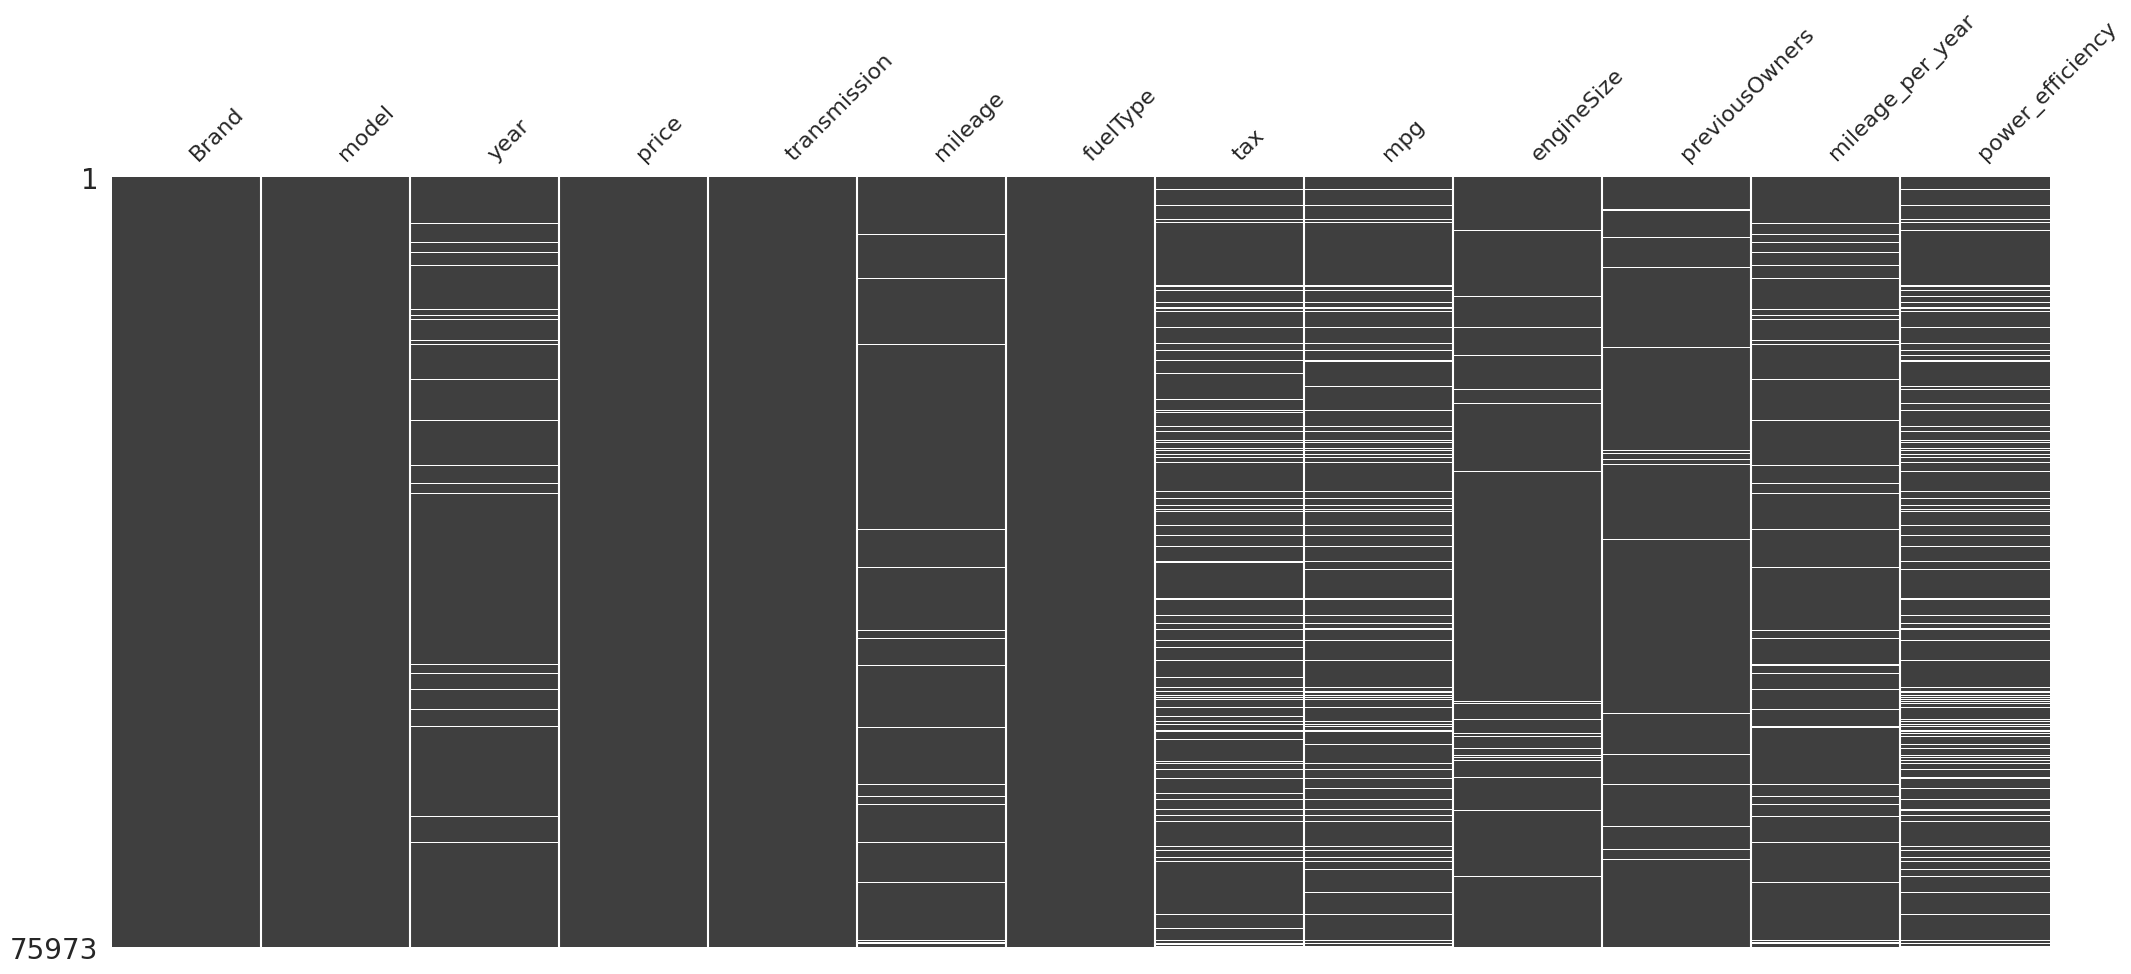

In [293]:
# Plot missing values matrix without the sparkline
msno.matrix(df, sparkline=False)
plt.show()

### **3.4.1 Imputation Strategy Definition**

In [294]:
def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill

        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X

### **3.4.2 Application to Train and Validation Sets**

In [295]:
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)
X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
39423,Mercedes,ACLASS,1,SEMI-AUTO,3915.0,PETROL,145.000000,47.9,1.3,2,3915.0,0.027140
9016,BMW,5SERIES,1,SEMI-AUTO,5687.0,HYBRID,135.000000,156.9,2.0,3,5687.0,0.012747
24121,Ford,FIESTA,0,MANUAL,10.0,PETROL,145.000000,56.5,1.0,0,10.0,0.017699
57460,Opel,MOKKAX,2,MANUAL,21600.0,UNKNOWN,145.000000,39.2,1.4,0,10800.0,0.035714
1936,Audi,RS4,0,SEMI-AUTO,3000.0,PETROL,145.000000,29.1,2.9,1,3000.0,0.099656
...,...,...,...,...,...,...,...,...,...,...,...,...
33819,Hyundai,I30,3,AUTOMATIC,19367.0,PETROL,121.445982,51.4,1.4,4,6455.666667,0.027237
46982,Skoda,KAROQ,1,MANUAL,100.0,DIESEL,145.000000,42.8,2.0,2,100.0,0.046729
71103,VW,UP,5,MANUAL,48429.0,PETROL,20.000000,62.8,1.0,1,9685.8,0.015924


In [296]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             53181 non-null  object 
 1   model             53181 non-null  object 
 2   year              53181 non-null  Int64  
 3   transmission      53181 non-null  object 
 4   mileage           53181 non-null  float64
 5   fuelType          53181 non-null  object 
 6   tax               53181 non-null  float64
 7   mpg               53181 non-null  float64
 8   engineSize        53181 non-null  float64
 9   previousOwners    53181 non-null  Int64  
 10  mileage_per_year  53181 non-null  Float64
 11  power_efficiency  53181 non-null  float64
dtypes: Float64(1), Int64(2), float64(5), object(4)
memory usage: 5.4+ MB


In [297]:
X_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22792 entries, 7082 to 74279
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             22792 non-null  object 
 1   model             22792 non-null  object 
 2   year              22792 non-null  Int64  
 3   transmission      22792 non-null  object 
 4   mileage           22792 non-null  float64
 5   fuelType          22792 non-null  object 
 6   tax               22792 non-null  float64
 7   mpg               22792 non-null  float64
 8   engineSize        22792 non-null  float64
 9   previousOwners    22792 non-null  Int64  
 10  mileage_per_year  22792 non-null  Float64
 11  power_efficiency  22792 non-null  float64
dtypes: Float64(1), Int64(2), float64(5), object(4)
memory usage: 2.3+ MB


## **3.5 Exploratory verification of Numerical Features**

In [298]:
def plot_nums(X, num_cols):
    outlier_counts=[]
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")
    plt.tight_layout()
    plt.show()
    for item in num_cols:
    #   find and count the outliers of metric features
        q1 = X[item].quantile(0.25)
        q3 = X[item].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        lower_outliers = (X[item] < lower).sum()
        upper_outliers = (X[item] > upper).sum()
        lower_pct = (lower_outliers / len(X)) * 100
        upper_pct = (upper_outliers / len(X)) * 100
        #create a dictionary with the feature,#outlier and percentage of outliers
        outlier_counts.append({
        "Feature": item,
        "Lower Outlier Count": lower_outliers,
        "Upper Outlier Count": upper_outliers,
        "Lower Outlier %": lower_pct,
        "Upper Outlier %": upper_pct
    })
    df_outlier = pd.DataFrame(outlier_counts)
    return df_outlier

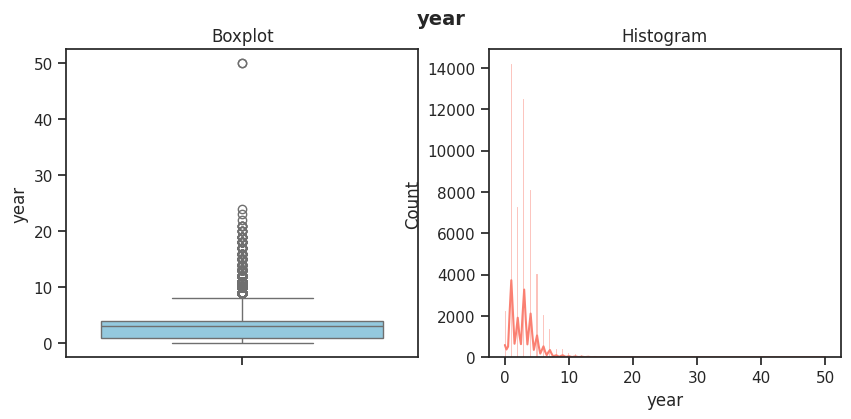

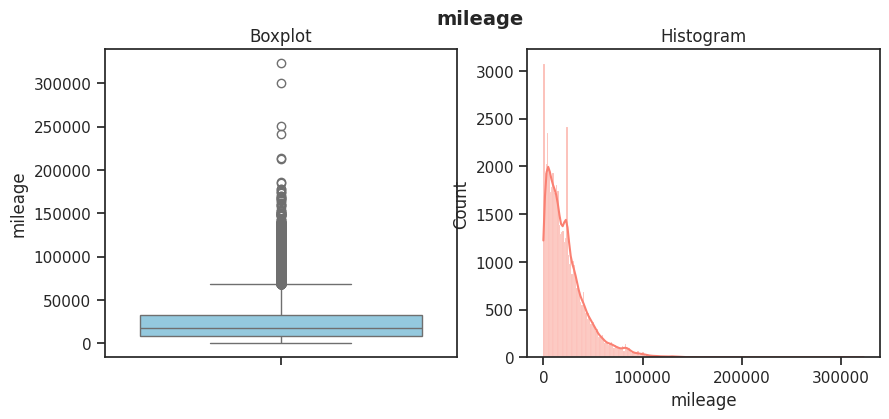

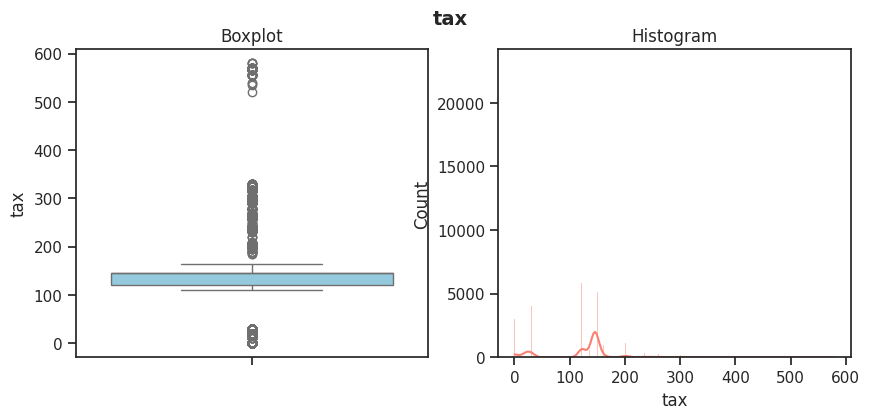

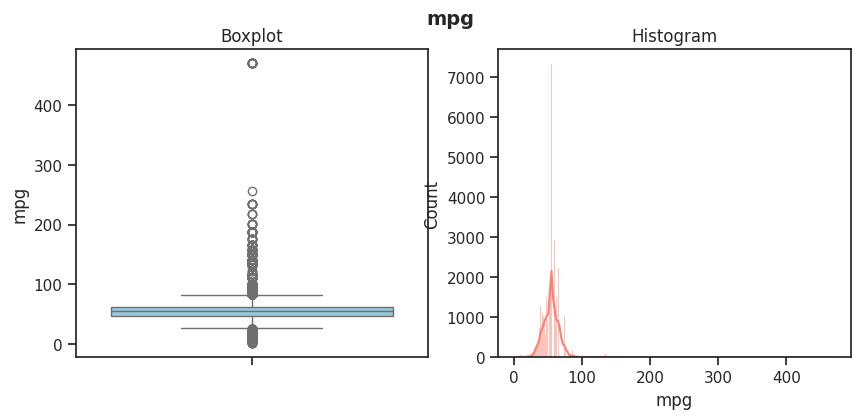

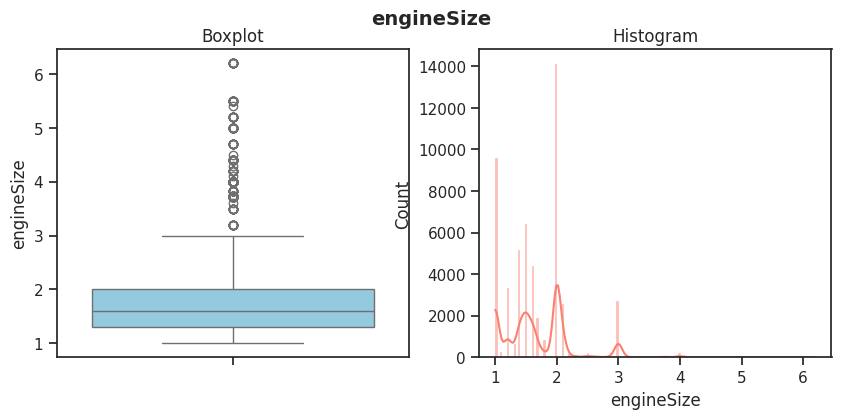

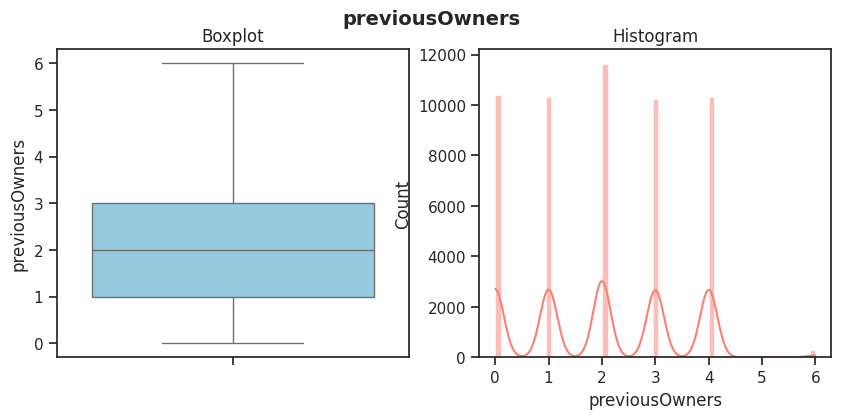

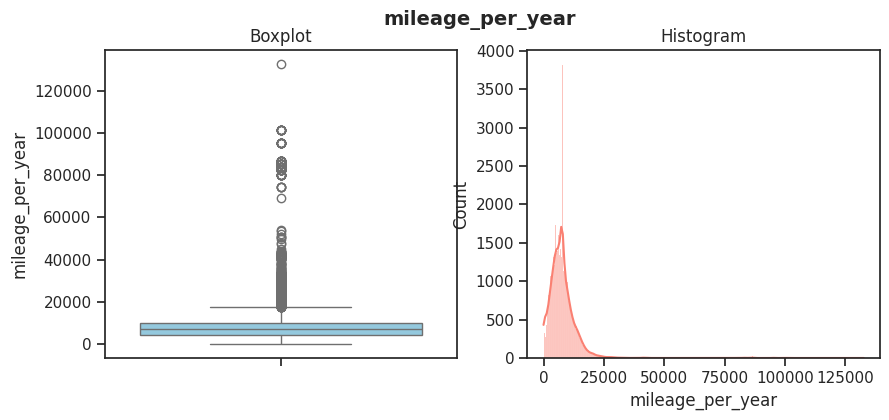

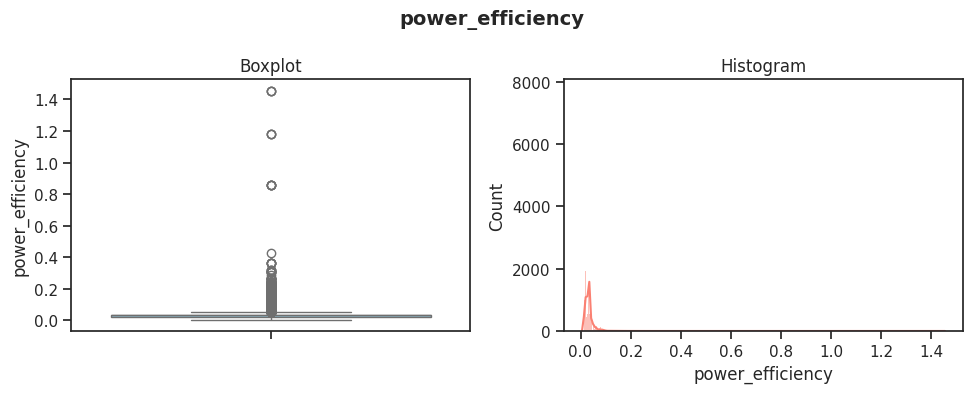

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,1082,0.000000,2.034561
1,mileage,0,2424,0.000000,4.558019
2,tax,10941,2942,20.573137,5.532051
3,mpg,353,870,0.663771,1.635923
4,engineSize,0,458,0.000000,0.861210
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,0,1666,0.000000,3.132698
7,power_efficiency,0,3853,0.000000,7.245069


In [299]:
plot_nums(X_train, num_cols)

## **3.6 Outlier Treatment & Skewness Correction**


### **3.6.1 Outlier & Skewness Strategy (Training Phase)**

To handle outliers a way had to be found in order to 1) detect skewed distributions automatically in order to log transform them, 2) to automatically define the winsorization quartiles to clip outliers. All this would have to be estabilished in the training fold and then passed on to the test fold to ensure no leakage. In order to decide if a log transform should happen or not to a feature we simply apply the skew() function and if it's absolute value is greater than one, we consider a log transform for the feature necessary. To define winsorization quartiles we use the MAD method: we take the median, calculate all deviations from it and do the median of that (=MAD), we then use robust z scores: z = (Xi - median(X))/(1.4826*MAD) (1.4826 assuming our distributions resemble a normal distribution now), if abs(z) > 3.5 it is an outlier, we choose clipping bounds based on inliers and clip according to quartiles we want, the default is 0.001 and 0.999. Normally outlier winsorization is handled with the IQR method, but since most features are skewed and have tails even after transforming we need something more robust like MAD.

In [300]:

def outliers_skews_train(
    X,
    num_cols,
    *,
    q_low=0.001,
    q_high=0.999,
    upper_only_after_log=False,
):
    """
    1) For each numeric column:
    compute skewness on raw values → decide log

    2) log-transform first (if decided)

    3) compute MAD robust z-scores on working scale

    4) define clipping bounds using quantiles of the inliers

    5) apply transforms

    6) return transformed data + metadata to replay on test
    """
    X = X.copy()
    info = {}

    for col in num_cols:
        x_raw = X[col].to_numpy()

        col_info = {
            "log": False,
            "clip": False,
            "lower": None,
            "upper": None,
            "q_low": float(q_low),
            "q_high": float(q_high),
            "mad_z": float(3.5),
            "skew_raw": None,
            "upper_only": False,
        }

        #not enough data
        if len(x_raw) < 20:
            info[col] = col_info
            continue

        #log transform if skewness > 1 and non negative values
        s = float(skew(x_raw))
        col_info["skew_raw"] = s
        do_log = (s > 1) and np.all(x_raw >= 0)
        col_info["log"] = bool(do_log)
        col_info["upper_only"] = bool(do_log and upper_only_after_log)

        # scale
        x_work = np.log1p(x_raw) if do_log else x_raw

        # (3) MAD robust z-scores on working scale
        med = np.median(x_work)
        mad = np.median(np.abs(x_work - med))
        #if mad~0 the columns is mostly constant
        if mad < 1e-12:
            info[col] = col_info
            # still apply log if chosen (even if clipping is skipped)
            if do_log:
                X[col] = np.log1p(X[col])
            continue

        scale = 1.4826 * mad
        rz = (x_work - med) / scale
        inliers = np.abs(rz) <= 3.5

        # If nothing to clip, still apply log if needed and move on
        if inliers.all():
            info[col] = col_info
            if do_log:
                X[col] = np.log1p(X[col])
            continue

        # (4) Quantile bounds computed on INLIERS (still on working scale)
        x_in = x_work[inliers]
        upper = float(np.quantile(x_in, q_high))
        lower = float(np.quantile(x_in, q_low))

        col_info["clip"] = True
        col_info["upper"] = upper
        col_info["lower"] = None if col_info["upper_only"] else lower

        # (5) Apply to training data: log -> clip (bounds are on working scale)
        if do_log:
            X[col] = np.log1p(X[col])

        if col_info["upper_only"]:
            X[col] = X[col].clip(upper=upper)
        else:
            X[col] = X[col].clip(lower=lower, upper=upper)

        info[col] = col_info

    return X, info

def outliers_skews_test(X, info):
    """
    Apply the transformations learned in outliers_skews_train to test/val data.

    For each column:
      1) Apply log1p if info[col]["log"] is True
      2) Apply clipping using stored bounds (on the same scale)
    """
    X = X.copy()

    for col, col_info in info.items():
        if col not in X.columns:
            continue

        x = X[col].to_numpy()
        if np.isnan(x).any():
            raise ValueError(f"NaNs found in '{col}' before log/MAD clipping (test/val).")

        # 1) Apply log transform if training decided so
        if col_info.get("log", False):
            X[col] = np.log1p(X[col])

        # 2) Apply clipping if training decided so
        if col_info.get("clip", False):
            lower = col_info.get("lower", None)
            upper = col_info.get("upper", None)

            if lower is None and upper is not None:
                X[col] = X[col].clip(upper=upper)
            elif lower is not None and upper is not None:
                X[col] = X[col].clip(lower=lower, upper=upper)
            elif lower is not None:
                X[col] = X[col].clip(lower=lower)

    return X

### **3.6.2 Application of Outlier & Skewness Corrections**

In [301]:
X_train, outlier_info = outliers_skews_train(X_train, num_cols)
X_val = outliers_skews_test(X_val, outlier_info)

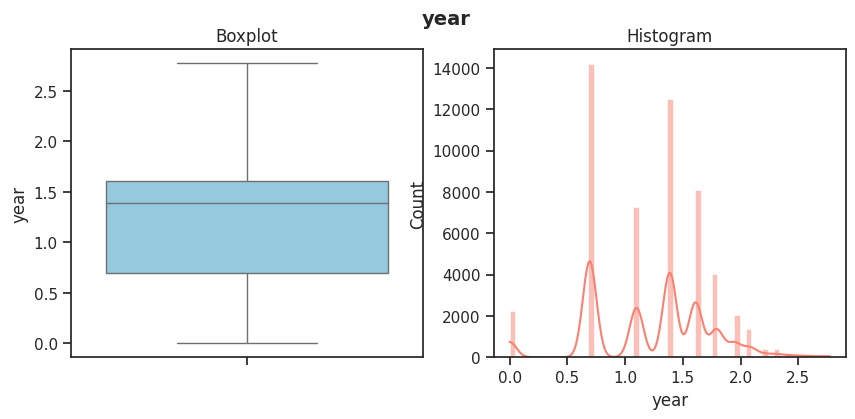

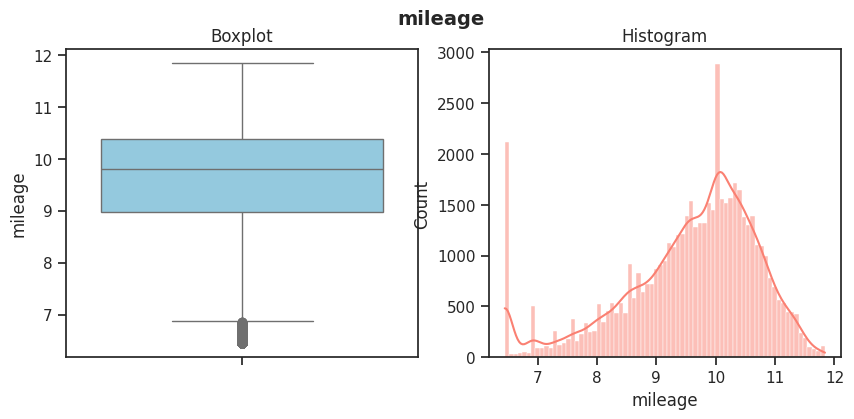

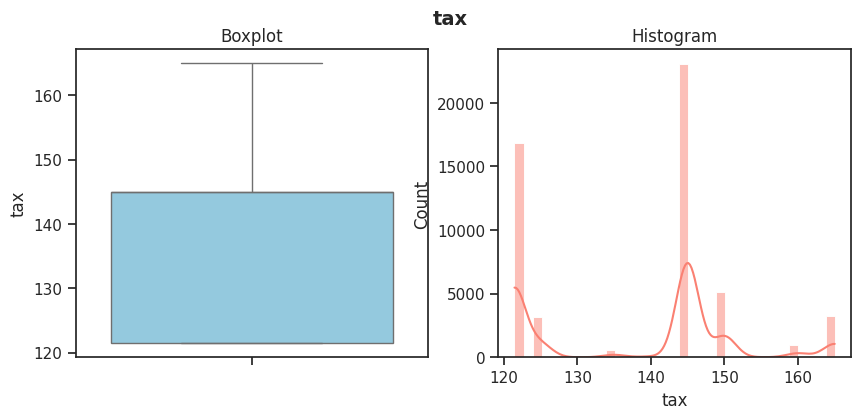

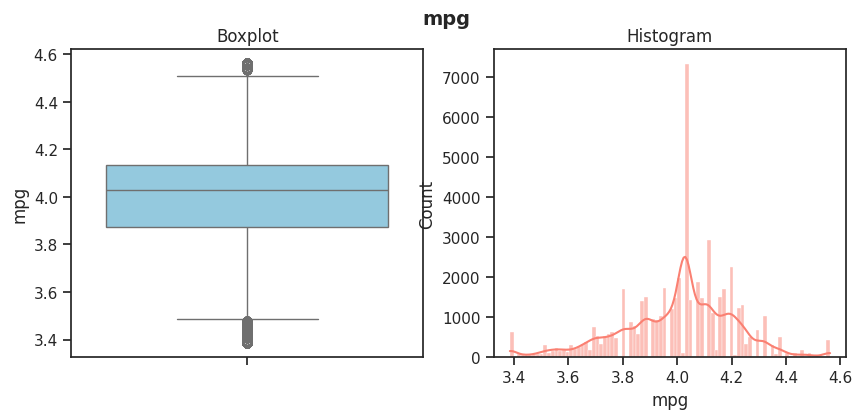

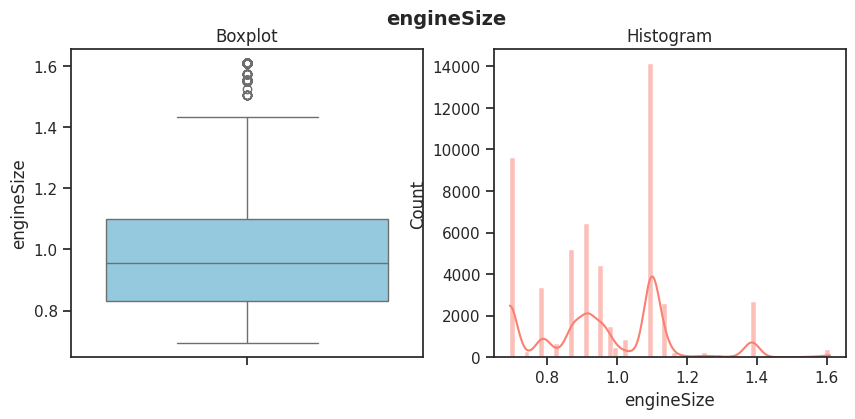

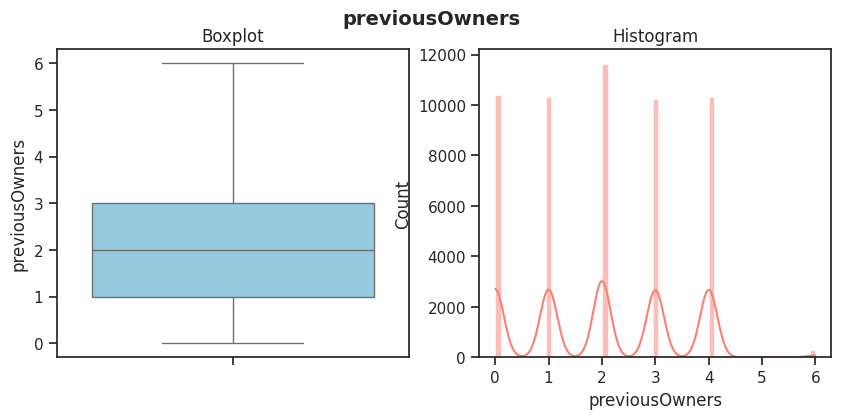

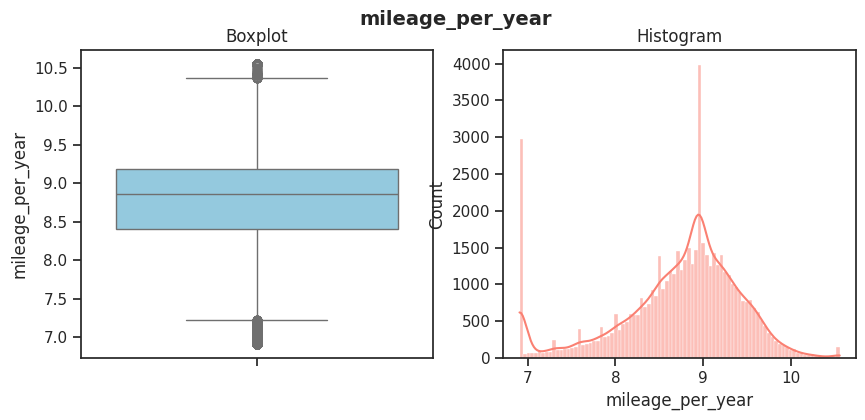

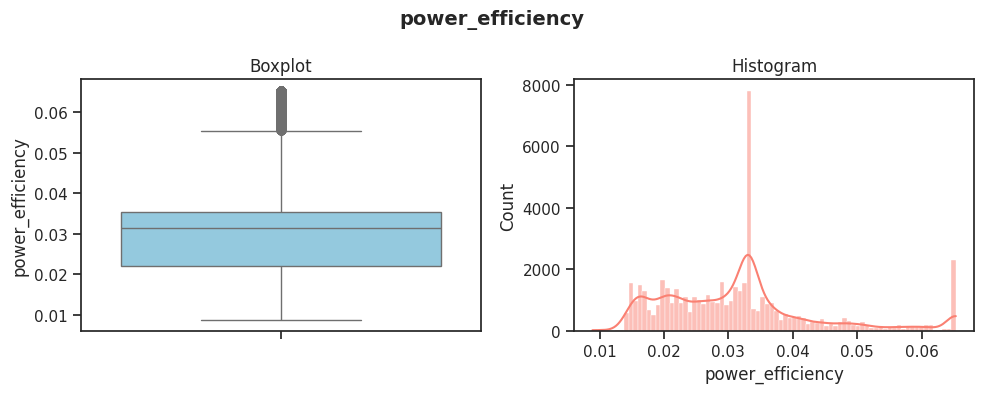

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,0,0.000000,0.000000
1,mileage,2299,0,4.322972,0.000000
2,tax,0,0,0.000000,0.000000
3,mpg,964,457,1.812677,0.859329
4,engineSize,0,446,0.000000,0.838645
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,3440,192,6.468476,0.361031
7,power_efficiency,0,3800,0.000000,7.145409


In [302]:
plot_nums(X_train, num_cols)

In [303]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()

## **3.7 Feature Scaling (Numerical Variables)**

In [304]:
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[0.25      , 0.33847287, 0.54080012, ..., 0.33333333, 0.37430552,
        0.31716213],
       [0.25      , 0.40769391, 0.31120018, ..., 0.5       , 0.47673693,
        0.06705062],
       [0.        , 0.        , 0.54080012, ..., 0.        , 0.        ,
        0.15350494],
       ...,
       [0.64624063, 0.80485352, 0.        , ..., 0.16666667, 0.62283069,
        0.12255596],
       [0.5       , 0.75595345, 0.08160024, ..., 0.66666667, 0.69063397,
        0.3188441 ],
       [0.64624063, 0.78657515, 0.08160024, ..., 0.        , 0.5957852 ,
        0.451278  ]])

In [305]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
39423,0.250000,0.338473,0.5408,0.429120,0.152530,0.333333,0.374306,0.317162
9016,0.250000,0.407694,0.3112,1.000000,0.442507,0.500000,0.476737,0.067051
24121,0.000000,0.000000,0.5408,0.566679,0.000000,0.000000,0.000000,0.153505
57460,0.396241,0.655136,0.5408,0.262774,0.198978,0.000000,0.652706,0.464503
1936,0.000000,0.289124,0.5408,0.017096,0.728840,0.166667,0.301280,1.000000
...,...,...,...,...,...,...,...,...
33819,0.500000,0.634902,0.0000,0.487817,0.198978,0.666667,0.511519,0.318844
46982,0.250000,0.000000,0.5408,0.335598,0.442507,0.333333,0.000000,0.651997
71103,0.646241,0.804854,0.0000,0.654957,0.000000,0.166667,0.622831,0.122556


In [306]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
7082,0.250000,0.395465,0.5408,0.196920,0.442507,0.166667,0.458641,0.795671
40497,0.580482,0.690971,0.0000,0.546980,0.478292,0.500000,0.515551,0.431802
46065,0.646241,0.780296,1.0000,0.008591,1.000000,0.500000,0.586495,1.000000
17155,0.396241,0.633537,0.5408,0.533554,0.000000,0.666667,0.620746,0.165989
34462,0.396241,0.733707,0.5408,0.230485,0.610740,0.166667,0.768968,0.980538
...,...,...,...,...,...,...,...,...
50530,0.500000,0.636703,0.5408,0.636118,0.000000,0.333333,0.514183,0.128889
41012,0.250000,0.269867,0.5408,0.546980,0.442507,0.333333,0.272785,0.431802
68389,0.500000,0.735229,0.0000,0.673388,0.000000,0.333333,0.659968,0.116497


## **3.8 Preprocessing Summary**

At the end of this preprocessing stage, the dataset is fully prepared for model
training. Missing values were handled using training-derived statistics, highly
skewed variables were stabilised, and extreme outliers were clipped based on
robust quantile thresholds.

All numerical features were subsequently normalised using Min–Max scaling to
ensure comparable feature ranges and to support models sensitive to scale.

Most importantly, every transformation applied to the validation data strictly
reused parameters learned from the training set, guaranteeing a leakage-free
pipeline and realistic performance estimates.

The resulting processed datasets are now suitable for direct integration into
the modelling pipeline.


# **4. FEATURE SELECTION**

Our feature selection strategy focused on maintaining a dual logic gate to ensure high quality features are retained:  
Our first gate is a noise gate ,created by shufling our target data, so there's no connection bettween features and target , this creates a baseline of noise . We then compare our feature with this null distribution and if a feature isn't 95% better than this random distribution it fails the test.  
In our second gate,we compare all features against each other and if a feature isn't on the top 50% , the feature fails.


## **4.1 Dataset Overview (Updated)**

- **Total Features**: 15 (excluding target)
- **Target Variable**: `price` (Selling price in £)
- **Size**: ~79,000 rows

| Feature            | Description |
|--------------------|-------------|
| `carID`            | Unique identifier for each car (to be dropped) |
| `Brand`            | Car's brand (e.g. Ford, Toyota) |
| `model`            | Car model name |
| `year`             | Year of registration |
| `mileage`          | Total distance driven (in miles) |
| `mileage_per_year` | Average mileage per year (`mileage / vehicle_age`) |
| `tax`              | Annual tax cost in £ (2020) |
| `fuelType`         | Type of fuel (Diesel, Petrol, Hybrid, Electric) |
| `mpg`              | Miles per gallon |
| `engineSize`       | Engine capacity in liters |
| `power_efficiency` | Fuel efficiency relative to engine size (`mpg / engineSize`) |
| `paintQuality%`    | Mechanic-assessed paint & hull condition (%) |
| `previousOwners`   | Number of previous owners |
| `hasDamage`        | Indicates if the car is damaged (Boolean) |


## **4.2 Numeric Features**

### **4.2.1 Spearman**

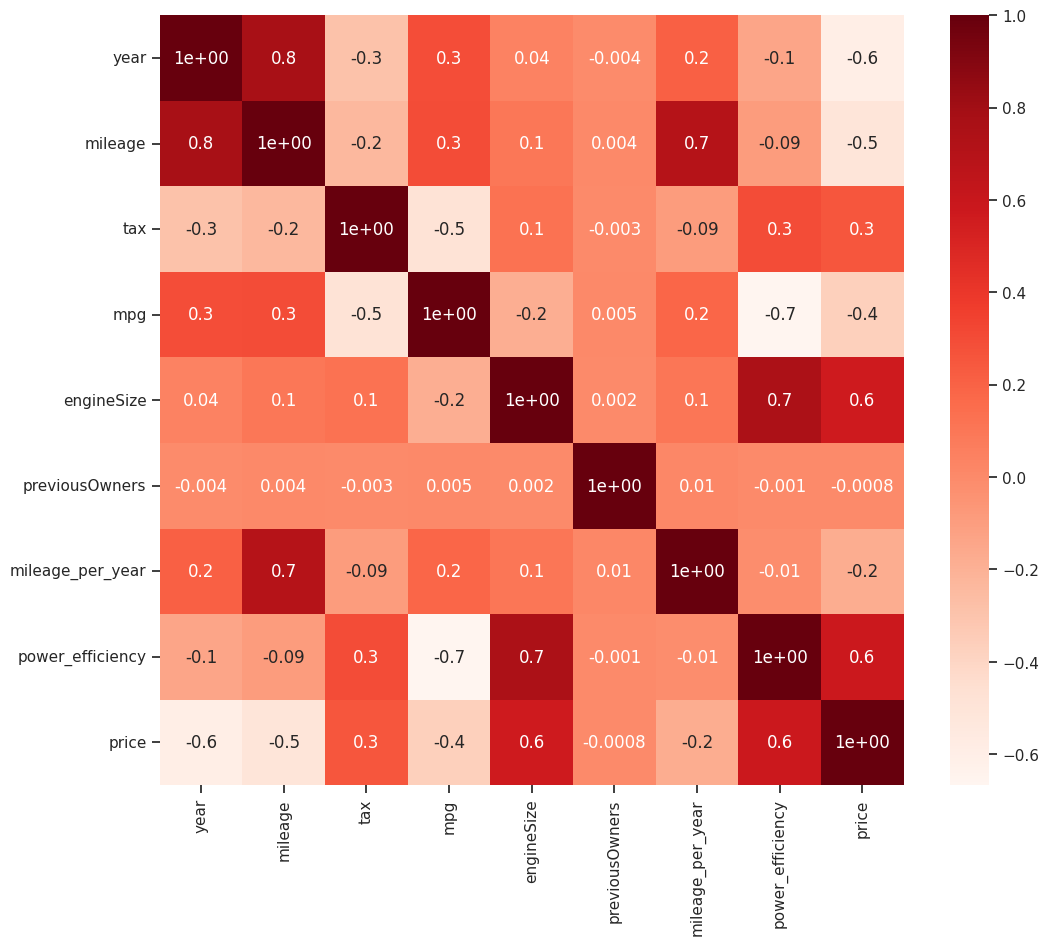

In [307]:
corr = X_train_num_scaled.assign(price=y_train).corr(method="spearman")
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [308]:
def spearman_decision_null(
    X_num,
    y,
    null_percentile=95,
    min_rank_pct=50,
    n_permutations=100,
):
    true_vals = {}
    null_vals = []
    #compute true mutual spearman score
    for col in X_num.columns:
        rho, _ = spearmanr(X_num[col], y)
        true_vals[col] = abs(rho)
    #compute null mutual spearman score
        for _ in range(n_permutations):
            y_perm = np.random.permutation(y)
            rho_null, _ = spearmanr(X_num[col], y_perm)
            null_vals.append(abs(rho_null))

    true_s = pd.Series(true_vals)

    null_thr = np.percentile(null_vals, null_percentile)
    rank_thr = np.percentile(true_s, min_rank_pct)

    decision = (true_s >= null_thr) & (true_s >= rank_thr)

    return pd.DataFrame(
        {
            "value": true_s,
            "decision": decision,
        }
    )

In [309]:
spearman = spearman_decision_null(X_train_num_scaled, y_train)
print(spearman)

                     value  decision
year              0.590326      True
mileage           0.508229      True
tax               0.255551     False
mpg               0.365796     False
engineSize        0.567154      True
previousOwners    0.000763     False
mileage_per_year  0.176689     False
power_efficiency  0.579094      True


### **4.2.2 Mutual Info**

In [310]:
def mi_scores_decision_null(
    X_num,
    y,
    null_percentile=95,
    min_rank_pct=50,
    n_permutations=20,
):
    true_vals = {}
    null_vals = []
    #compute true mutual information score
    for col in X_num.columns:
        x = X_num[[col]].values

        mi = mutual_info_regression(
            x, y, random_state=RANDOM_SEED
        )[0]
        true_vals[col] = mi
    #compute null mutual information score
        for _ in range(n_permutations):
            y_perm = np.random.permutation(y)
            mi_null = mutual_info_regression(
                x, y_perm
            )[0]
            null_vals.append(mi_null)

    true_s = pd.Series(true_vals)

    null_thr = np.percentile(null_vals, null_percentile)
    rank_thr = np.percentile(true_s, min_rank_pct)

    decision = (true_s >= null_thr) & (true_s >= rank_thr)

    return pd.DataFrame({
        "value": true_s,
        "decision": decision
    })

In [311]:
mi = mi_scores_decision_null(X_train_num_scaled, y_train)
print(mi)

                     value  decision
year              0.326860      True
mileage           0.292466     False
tax               0.128806     False
mpg               0.366600      True
engineSize        0.383895      True
previousOwners    0.000000     False
mileage_per_year  0.135160     False
power_efficiency  0.653148      True


### **4.2.3 Permutation Importance - Decision Tree**

In [312]:
def permutation_decision_null(
    X_train,
    y_train,
    X_val,
    y_val,
    null_percentile=95,
    min_rank_pct=50,
    n_null_models=10,
):
    #compute true permutation tree scores
    model = DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=10,
        random_state=RANDOM_SEED
    )
    model.fit(X_train, y_train)

    perm = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=5,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_SEED
    )

    true_vals = perm.importances_mean

    #compute null permutation tree scores
    null_vals = []

    for i in range(n_null_models):
        y_train_perm = np.random.permutation(y_train)
        y_val_perm = np.random.permutation(y_val)

        null_model = DecisionTreeRegressor(
            max_depth=5,
            min_samples_leaf=10,
            random_state=RANDOM_SEED + i
        )
        null_model.fit(X_train, y_train_perm)

        perm_null = permutation_importance(
            null_model,
            X_val,
            y_val_perm,
            n_repeats=5,
            scoring="neg_mean_absolute_error"
        )

        null_vals.extend(perm_null.importances_mean)

    null_thr = np.percentile(null_vals, null_percentile)
    rank_thr = np.percentile(true_vals, min_rank_pct)

    decision = (true_vals >= null_thr) & (true_vals >= rank_thr)

    return pd.DataFrame(
        {
            "value": true_vals,
            "decision": decision,
        },
        index=X_train.columns,
    )

In [313]:
perm=permutation_decision_null(X_train_num_scaled, y_train, X_val_num_scaled, y_val)
print(perm)

                        value  decision
year              2411.209263      True
mileage            447.722499      True
tax                  0.313996     False
mpg                 78.243165     False
engineSize        2931.756559      True
previousOwners       0.000000     False
mileage_per_year    33.326402     False
power_efficiency   772.256356      True


### **4.2.4 Lasso - The tie breaker**

In [314]:
def lasso_decision(X_train_num_scaled,y_train):
    reg = LassoCV(cv=5, random_state=RANDOM_SEED)
    reg.fit(X_train_num_scaled, y_train)
    coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)
    #for a feature to pass the test it has to have a greater coef than 1% of best feature(in absolute terms).
    return (coef.abs() > 0.1 * coef.abs().max())

In [315]:
lasso_keep = lasso_decision(X_train_num_scaled, y_train)
print(lasso_keep)

year                 True
mileage              True
tax                 False
mpg                  True
engineSize           True
previousOwners      False
mileage_per_year     True
power_efficiency    False
dtype: bool


## **4.3 Categorical Features**

### **4.3.1 Kruskal**

In [316]:
def kruskal_eta_squared_decision_null(
    X_cat,
    y,
    null_percentile=95,
    min_rank_pct=50,
    min_group_size=10,
    n_permutations=50,
):
    true_vals = {}
    null_vals = []

    y_arr = np.asarray(y)

    for col in X_cat.columns:
        x = X_cat[col].values

        groups_idx = [
            np.where(x == level)[0]
            for level in np.unique(x)
            if np.sum(x == level) >= min_group_size
        ]

        if len(groups_idx) < 2:
            true_vals[col] = 0.0
            continue

        #compute true kruskal scores
        groups = [y_arr[idx] for idx in groups_idx]

        k = len(groups)
        n = sum(len(g) for g in groups)

        h_stat, _ = kruskal(*groups)
        eta_true = max(0, (h_stat - k + 1) / (n - k))
        true_vals[col] = eta_true

       #compute null kruskal scores
        for _ in range(n_permutations):
            y_perm = np.random.permutation(y_arr)
            null_groups = [y_perm[idx] for idx in groups_idx]

            h_null, _ = kruskal(*null_groups)
            eta_null = max(0, (h_null - k + 1) / (n - k))
            null_vals.append(eta_null)

    true_s = pd.Series(true_vals)

    null_thr = (
        np.percentile(null_vals, null_percentile)
        if len(null_vals) > 0
        else 0.0
    )

    rank_thr = np.percentile(true_s, min_rank_pct)

    decision = (true_s >= null_thr) & (true_s >= rank_thr)

    return pd.DataFrame({
        "value": true_s,
        "decision": decision,
    })


In [317]:
kruskal_cat = kruskal_eta_squared_decision_null(X_train_cat,y_train)
print(kruskal_cat)

                 value  decision
Brand         0.343302     False
model         0.604633      True
transmission  0.358805      True
fuelType      0.077077     False


### **4.3.2 Mutual Info Categorical**

In [318]:
def mi_categorical_decision_null(
    X_cat,
    y,
    null_percentile=95,
    min_rank_pct=50,
    n_permutations=20,
):
    true_vals = {}
    null_vals = []

    y_arr = np.asarray(y)

    for col in X_cat.columns:
        x = (
            X_cat[col]
            .astype("category")
            .cat.codes
            .values
            .reshape(-1, 1)
        )

         #compute true mi scores
        mi = mutual_info_regression(
            x,
            y_arr,
            discrete_features=True,
            random_state=RANDOM_SEED,
        )[0]
        true_vals[col] = mi

         #compute null mi scores
        for _ in range(n_permutations):
            y_perm = np.random.permutation(y_arr)
            mi_null = mutual_info_regression(
                x,
                y_perm,
                discrete_features=True,
                random_state=RANDOM_SEED,
            )[0]
            null_vals.append(mi_null)

    true_s = pd.Series(true_vals)

    null_thr = (
        np.percentile(null_vals, null_percentile)
        if len(null_vals) > 0
        else 0.0
    )

    rank_thr = np.percentile(true_s, min_rank_pct)

    decision = (true_s >= null_thr) & (true_s >= rank_thr)

    return pd.DataFrame({
        "value": true_s,
        "decision": decision,
    })

In [319]:
mi_cat = mi_categorical_decision_null(X_train_cat,y_train)
print(mi_cat)

                 value  decision
Brand         0.324060      True
model         0.726926      True
transmission  0.247277     False
fuelType      0.070624     False


### **4.3.3 Permutation Importance - Decision Tree - Categorical**

In [320]:
def categorical_permutation_decision_null(
    X_train_cat,
    y_train,
    X_val_cat,
    y_val,
    null_percentile=95,
    min_rank_pct=50,
    n_null=10,
):
    #encode with ordinalEncoder
    encoder = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
    )

    X_train_enc = encoder.fit_transform(X_train_cat)
    X_val_enc = encoder.transform(X_val_cat)

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    model.fit(X_train_enc, y_train)

    #compute true importance
    perm_true = permutation_importance(
        model,
        X_val_enc,
        y_val,
        n_repeats=5,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    true_vals = np.maximum(perm_true.importances_mean, 0)

    #compute null importance for comprarision
    null_vals = []

    for _ in range(n_null):
        y_perm = np.random.permutation(y_val)

        perm_null = permutation_importance(
            model,
            X_val_enc,
            y_perm,
            n_repeats=5,
            scoring="neg_mean_absolute_error",
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

        null_vals.extend(
            np.maximum(perm_null.importances_mean, 0)
        )

    null_thr = np.percentile(null_vals, null_percentile)
    rank_thr = np.percentile(true_vals, min_rank_pct)

    decision = (true_vals >= null_thr) & (true_vals >= rank_thr)

    return pd.DataFrame(
        {
            "value": true_vals,
            "decision": decision,
        },
        index=X_train_cat.columns,
    )

In [321]:
perm_cat=categorical_permutation_decision_null(X_train_cat, y_train,X_val_cat, y_val)
perm_cat

,value,decision
Brand,1969.561718,True
model,1754.660257,True
transmission,1506.550388,False
fuelType,155.557023,False


## **4.4 - Voting Table**

In our voting table we will use spearman, mi and permutation importance, with permutation importance treated as the strongest signal.Lasso will be used to handle multicollineraty, here's our decision criteria for numerical features :  
If a feature fails permutation and both spearman and mutual information , we treat theese features has pure noise(NOISE).    
If a feature passes permutation and atleast one of the other tests(spearman or mi), we treat theese features has a major driver of price prediction(MAJOR).  
If a feature passes passes both spearman and mutual information, and fails permutation we keep the features(KEEP).  
If a features passes exactly one of the tests(spearman and mi) and fails permutatio we let Lasso decide if we keep (KEEP) or toss (TOSS).  

In our voting table we will use kruskal, mi and permutation importance,with permutation importance treated as the strongest signal,we will rank features in the following way:
If a feature doesn't have a single passing test , then we will treat this feature has pure noise by not include the feature in any of our model(NOISE).  
If a feature passes permutation importance and atleast one of the other tests we assume it's a major driver of price prediction (MAJOR).  
If a features passes both krustal and mi but fails permutation inportance we keep as a lesser signal(KEEP).
If a features passes exactly one of the krustal and mi test,then we let permutation decide if we keep (KEEP) or toss (TOSS) .

In [322]:
def decide_numerical(
    spearman: bool,
    mi: bool,
    permutation: bool,
    lasso: bool = False,
):
    votes = sum([spearman, mi])

    if not permutation and votes == 0:
        final = "NOISE"

    elif permutation and votes >= 1:
        final = "MAJOR"

    elif votes == 2:
        final = "KEEP"

    elif votes == 1:
        final = "KEEP" if lasso else "TOSS"

    else:
        final = "NOISE"

    return {
        "spearman": spearman,
        "mi": mi,
        "permutation": permutation,
        "lasso": lasso,
        "final_decision": final,
    }

In [323]:
numerical_decisions = {}

for col in X_train_num_scaled.columns:
    numerical_decisions[col] = decide_numerical(
        spearman=spearman.loc[col, "decision"],
        mi=mi.loc[col, "decision"],
        permutation=perm.loc[col, "decision"],
        lasso=lasso_keep[col],
    )

numerical_results = pd.DataFrame(numerical_decisions).T
print(numerical_results)

                 spearman     mi permutation  lasso final_decision
year                 True   True        True   True          MAJOR
mileage              True  False        True   True          MAJOR
tax                 False  False       False  False          NOISE
mpg                 False   True       False   True           KEEP
engineSize           True   True        True   True          MAJOR
previousOwners      False  False       False  False          NOISE
mileage_per_year    False  False       False   True          NOISE
power_efficiency     True   True        True  False          MAJOR


In [324]:
def decide_categorical(
    kruskal: bool,
    mi: bool,
    permutation: bool,
):
    votes = sum([kruskal, mi])

    if votes == 0 and not permutation:
        final = "NOISE"

    elif permutation and votes >= 1:
        final = "MAJOR"

    elif votes == 2:
        final = "KEEP"

    elif permutation:
        final = "KEEP"

    else:
        final = "TOSS"

    return {
        "kruskal": kruskal,
        "mi": mi,
        "permutation": permutation,
        "final_decision": final,
    }

In [325]:
categorical_results = pd.DataFrame(index=X_train_cat.columns)

categorical_results["kruskal"] = kruskal_cat["decision"]
categorical_results["mi"] = mi_cat["decision"]
categorical_results["permutation"] = perm_cat["decision"]

categorical_results["final_decision"] = categorical_results.apply(
    lambda row: decide_categorical(
        kruskal=row["kruskal"],
        mi=row["mi"],
        permutation=row["permutation"],
    )["final_decision"],
    axis=1,
)
categorical_results

,kruskal,mi,permutation,final_decision
Brand,False,True,True,MAJOR
model,True,True,True,MAJOR
transmission,True,False,False,TOSS
fuelType,False,False,False,NOISE


In [326]:
major_num = numerical_results.query("final_decision == 'MAJOR'").index.tolist()
keep_num = numerical_results.query("final_decision == 'KEEP'").index.tolist()
toss_num = numerical_results.query("final_decision == 'TOSS'").index.tolist()
noise_num = numerical_results.query("final_decision == 'NOISE'").index.tolist()

numerical_final = major_num + keep_num
numerical_experimental = numerical_final + toss_num


major_cat = categorical_results.query("final_decision == 'MAJOR'").index.tolist()
keep_cat = categorical_results.query("final_decision == 'KEEP'").index.tolist()
toss_cat = categorical_results.query("final_decision == 'TOSS'").index.tolist()
noise_cat = categorical_results.query("final_decision == 'NOISE'").index.tolist()

categorical_final = major_cat + keep_cat
categorical_experimental = categorical_final + toss_cat

final_features=numerical_final+categorical_final
experimental_features=numerical_experimental+categorical_experimental

In [327]:
final_features

['year', 'mileage', 'engineSize', 'power_efficiency', 'mpg', 'Brand', 'model']

In [328]:
experimental_features #tested and kept on a per model analysis.

['year',
 'mileage',
 'engineSize',
 'power_efficiency',
 'mpg',
 'Brand',
 'model',
 'transmission']

Alltough our Feature Selection told us to drop certain features we also found that we simply had a better Kaggle performance by using all of them. This also led to us picking mostly tree-based models that are more robust to feature selection, since they split the data in order to reduce impurity by building trees with the most important features. We need to explicitly state whch columns are float features, int features and categorical feature as well as features we want to drop for our pipeline.

In [329]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize','previousOwners',"mileage_per_year","power_efficiency"]
cat_cols = ['Brand', 'model', 'transmission', 'fuelType']
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize',"mileage_per_year","power_efficiency"]

drop_cols=[]
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,3,3768.0,0.014925


In [330]:
#Feature Selection Features
"""cat_cols = ['Brand', 'model']
int_cols = ['year']
float_cols = ['mileage', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']
drop_cols = ['paintQuality%', 'previousOwners', 'fuelType',"transmission", "tax"]"""


'cat_cols = [\'Brand\', \'model\']\nint_cols = [\'year\']\nfloat_cols = [\'mileage\', \'mpg\', \'engineSize\', \'mileage_per_year\', \'power_efficiency\']\ndrop_cols = [\'paintQuality%\', \'previousOwners\', \'fuelType\',"transmission", "tax"]'

## **4.5 Results of Feature Selection**

The feature groups used in the modeling pipeline are defined as follows:

```python
cat_cols   = ['Brand', 'model']
int_cols   = ['year']
float_cols = ['mileage', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']
drop_cols  = ['paintQuality%', 'previousOwners', 'fuelType', 'transmission', 'tax']


# **5. MODEL SELECTION**

## **5.1 Model Selection Strategy**

## Model Selection Strategy

- A **controlled and reproducible model selection procedure** is implemented.
- The same **train–validation split** used in the Feature Selection stage is enforced via **`PredefinedSplit`**, ensuring:
  - No data leakage
  - Fair comparison across all candidate models
  - Evaluation on the **exact same validation set**

- A **RandomizedSearchCV-based hyperparameter search** was conducted over **five different model families**, allowing:
  - Efficient exploration of the hyperparameter space
  - Consistent evaluation under identical validation conditions
  - Fair model comparison within a fixed computational budget

- A **unified, leakage-safe preprocessing function** is used throughout the entire model selection process:
  - All transformations are **fitted exclusively on the training data**
  - The fitted transformations are consistently reused during validation, including:
    - One-Hot Encoder
    - Outlier thresholds (quartiles)
    - Transformation metadata
    - Mean and mode values for NaN imputation

- **Model-specific preprocessing rules** are conditionally applied, particularly for outlier handling:
  - While this introduces potential **selective bias**, it was handled pragmatically
  - Each model was evaluated **with and without outlier treatment**
  - The final choice was guided by **empirical validation and Kaggle performance**


## **5.2 Train–Validation Split and Validation Strategy**

In [331]:
#we copied the folds when we split the dataset since we already did the pre-processing on them beforew the feature selection stage
X_train = X_train_raw.drop(columns=drop_cols, errors="ignore")
X_val   = X_val_raw.drop(columns=drop_cols, errors="ignore")

y_train = y_train_raw
y_val   = y_val_raw

#-1 = train and 0 = validation
test_fold = np.concatenate([
    -1 * np.ones(len(X_train)),
     0 * np.ones(len(X_val))
])

ps = PredefinedSplit(test_fold)

#first train and then validation
y_train_val_full = pd.concat(
    [y_train, y_val],
    axis=0
).reset_index(drop=True)

X_train

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
39423,Mercedes,ACLASS,1,SEMI-AUTO,3915.0,PETROL,145.0,47.9,1.3,2,3915.0,0.027140
9016,BMW,5SERIES,1,SEMI-AUTO,5687.0,HYBRID,135.0,156.9,2.0,3,5687.0,0.012747
24121,Ford,FIESTA,0,MANUAL,10.0,PETROL,145.0,56.5,1.0,0,10.0,0.017699
57460,Opel,MOKKAX,2,MANUAL,21600.0,UNKNOWN,145.0,39.2,1.4,0,10800.0,0.035714
1936,Audi,RS4,0,SEMI-AUTO,3000.0,PETROL,145.0,29.1,2.9,1,3000.0,0.099656
...,...,...,...,...,...,...,...,...,...,...,...,...
33819,Hyundai,I30,3,AUTOMATIC,19367.0,PETROL,NaN,51.4,1.4,4,6455.666667,0.027237
46982,Skoda,KAROQ,1,MANUAL,100.0,DIESEL,145.0,42.8,2.0,2,100.0,0.046729
71103,VW,UP,5,MANUAL,48429.0,PETROL,20.0,62.8,1.0,1,9685.8,0.015924


## **5.3 Unified Custom Preprocessing**

- The preprocessing function accepts a DataFrame and behaves differently depending on the `fit` parameter.
- When `fit=True` (training data):
  - Median (numerical) and mode (categorical) values are computed for NaN imputation.
  - NaN values are imputed using these statistics.
  - Outlier quartiles are calculated.
  - A decision is made on whether variables should be log-transformed.
  - All learned preprocessing information is stored in an `artifacts` object.
- When `fit=False` (validation or test data):
  - The previously stored `artifacts` are reused.
  - NaN imputation, outlier handling, and transformations are applied consistently using training-derived statistics.
- No feature scaling is applied, as the modeling pipeline relies primarily on **tree-based models**, which are invariant to feature scaling.


In [332]:
def preprocess_for_search(
    X,
    int_cols,
    float_cols,
    cat_cols,
    ohe,
    apply_outliers=True,
    fit=True,
    fill_values=None,
    outlier_info=None
):
    """
    Returns:
    - X_final: preprocessed feature matrix
    - artifacts: dict with learned preprocessing objects
    """

    X = X.copy()
    artifacts = {}
    num_cols = int_cols + float_cols

    #Numerical imputation
    if fit:
        X, fill_values = fill_nans(X, int_cols, float_cols)
        artifacts["fill_values"] = fill_values
    else:
        X = fill_nans(X, int_cols, float_cols, fill_values)

    #Outlier and skew correction
    if apply_outliers:
        if fit:
            X, outlier_info = outliers_skews_train(X, num_cols)
            artifacts["outlier_info"] = outlier_info
        else:
            X = outliers_skews_test(X, outlier_info)

    #One-Hot-Encoding
    if fit:
        ohe.fit(X[cat_cols])

    encoded = ohe.transform(X[cat_cols])
    encoded_cols = ohe.get_feature_names_out(cat_cols)

    X_encoded = pd.DataFrame.sparse.from_spmatrix(
    encoded,
    columns=encoded_cols,
    index=X.index
)

    #Return unified dataset
    X_final = pd.concat(
        [X.drop(columns=cat_cols), X_encoded],
        axis=1
    )

    X_final.columns = X_final.columns.astype(str)

    return X_final, artifacts



## **5.4 Candidate Models and Hyperparameter Search Spaces**

- The model selection strategy was guided by the characteristics of the Feature Selection stage.
- Tree-based models were prioritized due to their robustness to:
  - Noisy or weakly informative features
  - Imperfect feature selection
  - Non-linear relationships in the data
- A Ridge Regression model was also included:
  - As a strong linear baseline for comparison
  - To provide regularization over standard linear regression
  - To reduce the influence of noisy or less important features


In [333]:

models = {
        "RandomForest": RandomForestRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1,
    ),

    "GradientBoosting": GradientBoostingRegressor(
        random_state=RANDOM_SEED
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=RANDOM_SEED
    ),

    "ExtraTrees": ExtraTreesRegressor(
        random_state=RANDOM_SEED,
        n_jobs=-1
    ),

    "Ridge": Ridge()
}


param_spaces = {
    "RandomForest": {
        "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
        "max_depth": [5, 7, 10, 15, 20, 25, 30],
        "min_samples_split": [2, 4, 5, 10, 12, 15],
        "min_samples_leaf": [1, 2, 5, 7, 10],
        "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
        "max_samples": [0.7, 0.8, 0.9],
        "bootstrap": [True]
    },

    "GradientBoosting": {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3, 4]
    },

    "HistGradientBoosting": {
        "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
        "max_iter": [200, 400, 800, 1200],
        "max_depth": [None, 3, 4, 5, 6, 8],
        "max_leaf_nodes": [15, 31, 63, 127],
        "min_samples_leaf": [10, 20, 30, 50, 80, 120],
        "l2_regularization": [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0],
        "max_bins": [64, 128, 255]
    },

    "ExtraTrees": {
        "n_estimators": [200, 300, 400, 600, 800],
        "max_depth": [None, 10, 20, 30, 40],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 5, 10, 20],
        "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],
        "bootstrap": [False]
    },

    "Ridge": {
        "alpha": [0.1, 1.0, 10.0]
    }
}


## **5.5 RandomizedSearchCV with Controlled Validation**


- Hyperparameter tuning was performed using **`RandomizedSearchCV`**, with **Mean Absolute Error (MAE)** as the optimization metric, as it aligns directly with the Kaggle competition evaluation criterion.
- Although `RandomizedSearchCV` is typically associated with cross-validation, no internal k-fold CV was used in this case:
  - A **fixed, pre-defined train–validation split** was employed instead.
  - This split corresponds to the previously established hold-out sets and is enforced via `PredefinedSplit`.
  - The scikit-learn function name reflects its general-purpose design rather than the specific validation strategy used here.
- For each model family, the randomized search was run for **15 iterations**, allowing:
  - Efficient exploration of the hyperparameter space
  - Consistent computational budget across models
- Final model selection was primarily based on **validation MAE**, while also considering:
  - The **bias–variance trade-off**
  - Signs of overfitting or underfitting observed during validation
- This approach ensures that the selected model balances **predictive accuracy** with **generalization performance**, rather than optimizing solely for the lowest validation error.


In [334]:
"""results = []

print("\n===== MODEL SELECTION STARTED =====\n")

for name, model in models.items():
    print(f"\n### Running: {name} ###")

    #Outlier handling
    apply_outliers = name not in [
        "GradientBoosting", "HistGradientBoosting"
    ]

    #Encoder
    ohe_model = OneHotEncoder(
        drop="first",
        sparse_output=True,
        handle_unknown="ignore"
    )

    X_train_proc, artifacts = preprocess_for_search(
        X_train,
        int_cols=int_cols,
        float_cols=float_cols,
        cat_cols=cat_cols,
        ohe=ohe_model,
        apply_outliers=apply_outliers,
        fit=True
    )

    X_val_proc, _ = preprocess_for_search(
        X_val,
        int_cols=int_cols,
        float_cols=float_cols,
        cat_cols=cat_cols,
        ohe=ohe_model,
        apply_outliers=apply_outliers,
        fit=False,
        fill_values=artifacts["fill_values"],
        outlier_info=artifacts.get("outlier_info")
    )

    #Predefined Split
    X_train_np = X_train_proc.to_numpy(dtype=np.float32, copy=False)
    X_val_np   = X_val_proc.to_numpy(dtype=np.float32, copy=False)

    X_full_np = np.vstack([X_train_np, X_val_np])
    y_full_np = y_train_val_full.to_numpy().ravel().astype(np.float32, copy=False)

    #RandomSearchCV
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_spaces[name],
        n_iter=15,
        cv=ps,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_SEED,
        error_score="raise",
        refit=False
    )

    search.fit(X_full_np, y_full_np)


    # Refit THIS model on TRAIN ONLY using best params, clone function is necessary because of the stateful models
    best_params = search.best_params_
    best_est = clone(model).set_params(**best_params)
    best_est.fit(X_train_np, y_train.to_numpy().ravel())

    # metrics
    y_train_pred = best_est.predict(X_train_np)
    y_val_pred   = best_est.predict(X_val_np)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae   = mean_absolute_error(y_val, y_val_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    val_r2   = r2_score(y_val, y_val_pred)

    print(f"\nModel: {name}")
    print(f"Outliers applied: {apply_outliers}")
    print(f"Train MAE: {train_mae:.4f} | Train R²: {train_r2:.4f}")
    print(f"Val   MAE: {val_mae:.4f} | Val   R²: {val_r2:.4f}")
    print("-" * 50)

    results.append({
        "model": name,
        "train_mae": train_mae,
        "val_mae": val_mae,
        "train_r2": train_r2,
        "val_r2": val_r2,
        "best_params": best_params,
        "estimator": best_est,
        "apply_outliers": apply_outliers,
        "search_best_cv_score": search.best_score_,
    })

print("\n===== MODEL SELECTION COMPLETE =====")

results_sorted = sorted(results, key=lambda x: x["val_mae"])
best = results_sorted[0]

print("\n### BEST MODEL ###")
print(best["model"], best["val_mae"], best["best_params"])"""

'results = []\n\nprint("\n===== MODEL SELECTION STARTED =====\n")\n\nfor name, model in models.items():\n    print(f"\n### Running: {name} ###")\n\n    #Outlier handling\n    apply_outliers = name not in [\n        "GradientBoosting", "HistGradientBoosting"\n    ]\n\n    #Encoder\n    ohe_model = OneHotEncoder(\n        drop="first",\n        sparse_output=True,\n        handle_unknown="ignore"\n    )\n\n    X_train_proc, artifacts = preprocess_for_search(\n        X_train,\n        int_cols=int_cols,\n        float_cols=float_cols,\n        cat_cols=cat_cols,\n        ohe=ohe_model,\n        apply_outliers=apply_outliers,\n        fit=True\n    )\n\n    X_val_proc, _ = preprocess_for_search(\n        X_val,\n        int_cols=int_cols,\n        float_cols=float_cols,\n        cat_cols=cat_cols,\n        ohe=ohe_model,\n        apply_outliers=apply_outliers,\n        fit=False,\n        fill_values=artifacts["fill_values"],\n        outlier_info=artifacts.get("outlier_info")\n    )\n\n 

In [335]:
hardcoded_results = [
    {
        "model": "RandomForest",
        "train_mae": 735.7248,
        "val_mae": 1393.3256,
        "train_r2": 0.9832,
        "val_r2": 0.9448,
        "best_params": {
            "n_estimators": 200,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "max_samples": 0.7,
            "max_features": 0.5,
            "max_depth": 30,
            "bootstrap": True
        },
        "estimator": RandomForestRegressor(
            n_estimators=200,
            min_samples_split=2,
            min_samples_leaf=1,
            max_samples=0.7,
            max_features=0.5,
            max_depth=30,
            bootstrap=True,
            random_state=1907,
            n_jobs=-1
        ),
        "apply_outliers": True
    },

    {
        "model": "GradientBoosting",
        "train_mae": 1834.7802,
        "val_mae": 1874.3986,
        "train_r2": 0.9207,
        "val_r2": 0.9158,
        "best_params": {
            "n_estimators": 200,
            "max_depth": 4,
            "learning_rate": 0.1
        },
        "estimator": GradientBoostingRegressor(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            random_state=1907
        ),
        "apply_outliers": False
    },

    {
        "model": "HistGradientBoosting",
        "train_mae": 1119.9991,
        "val_mae": 1370.5807,
        "train_r2": 0.9633,
        "val_r2": 0.9444,
        "best_params": {
            "min_samples_leaf": 30,
            "max_leaf_nodes": 127,
            "max_iter": 400,
            "max_depth": None,
            "max_bins": 128,
            "learning_rate": 0.1,
            "l2_regularization": 1.0
        },
        "estimator": HistGradientBoostingRegressor(
            min_samples_leaf=30,
            max_leaf_nodes=127,
            max_iter=400,
            max_depth=None,
            max_bins=128,
            learning_rate=0.1,
            l2_regularization=1.0,
            random_state=1907
        ),
        "apply_outliers": False
    },

    {
        "model": "ExtraTrees",
        "train_mae": 526.3264,
        "val_mae": 1309.5492,
        "train_r2": 0.9906,
        "val_r2": 0.9509,
        "best_params": {
            "n_estimators": 200,
            "min_samples_split": 5,
            "min_samples_leaf": 1,
            "max_features": 0.3,
            "max_depth": 30,
            "bootstrap": False
        },
        "estimator": ExtraTreesRegressor(
            n_estimators=200,
            min_samples_split=5,
            min_samples_leaf=1,
            max_features=0.3,
            max_depth=30,
            bootstrap=False,
            random_state=1907,
            n_jobs=-1
        ),
        "apply_outliers": True
    },

    {
        "model": "Ridge",
        "train_mae": 2472.8323,
        "val_mae": 2466.9797,
        "train_r2": 0.8393,
        "val_r2": 0.8482,
        "best_params": {
            "alpha": 0.1
        },
        "estimator": Ridge(alpha=0.1),
        "apply_outliers": True
    }
]


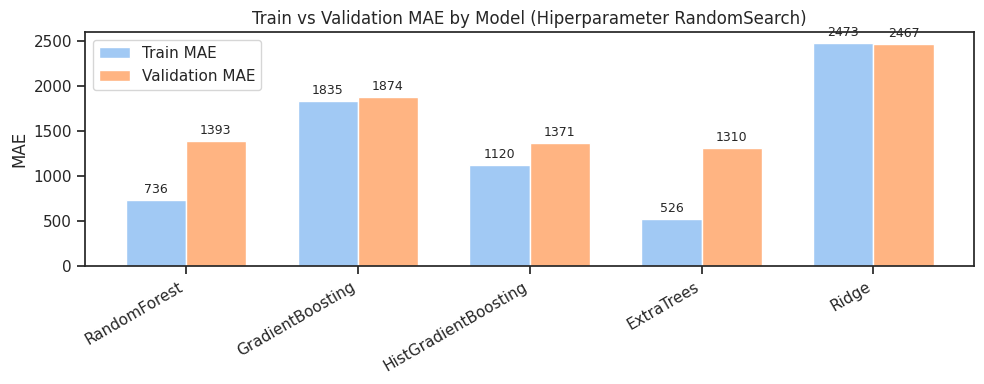

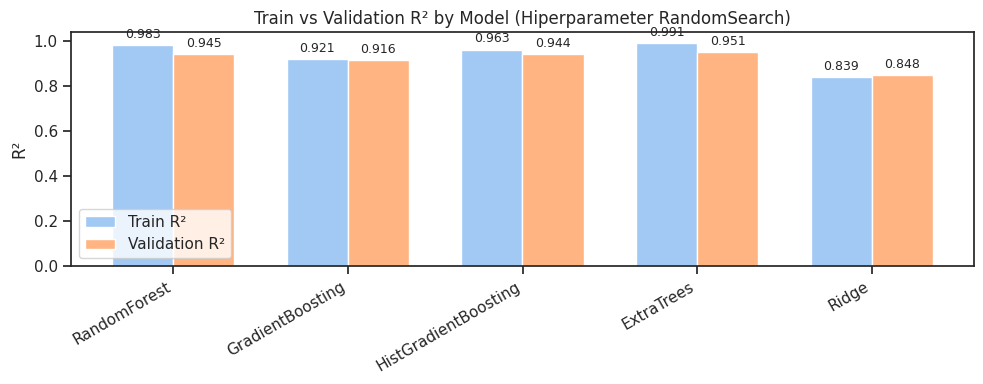

In [336]:
models    = [d["model"] for d in hardcoded_results]
train_mae = [d["train_mae"] for d in hardcoded_results]
val_mae   = [d["val_mae"]   for d in hardcoded_results]
train_r2  = [d["train_r2"]  for d in hardcoded_results]
val_r2    = [d["val_r2"]    for d in hardcoded_results]

x = np.arange(len(models))
width = 0.35

def add_bar_labels(ax, bars, fmt="{:.2f}", offset=3):
    """This function is necessary in order to add the exact metric value to each bar in the chart"""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            fmt.format(height),
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, offset),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9
        )

# MAE
fig, ax = plt.subplots(figsize=(10, 4))

bars_train = ax.bar(x - width/2, train_mae, width, label="Train MAE")
bars_val   = ax.bar(x + width/2, val_mae,   width, label="Validation MAE")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylabel("MAE")
ax.set_title("Train vs Validation MAE by Model (Hiperparameter RandomSearch)")
ax.legend()

add_bar_labels(ax, bars_train, fmt="{:.0f}")
add_bar_labels(ax, bars_val,   fmt="{:.0f}")

fig.tight_layout()
plt.show()

# R2
fig, ax = plt.subplots(figsize=(10, 4))

bars_train = ax.bar(x - width/2, train_r2, width, label="Train R²")
bars_val   = ax.bar(x + width/2, val_r2,   width, label="Validation R²")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylabel("R²")
ax.set_title("Train vs Validation R² by Model (Hiperparameter RandomSearch)")
ax.legend()

add_bar_labels(ax, bars_train, fmt="{:.3f}")
add_bar_labels(ax, bars_val,   fmt="{:.3f}")

fig.tight_layout()
plt.show()

The parallel tree-models, namely ExtraTrees and RandomForestRegressor, are some of the most performant but might be slightly overfitting due to their Validation and Training MAE difference, but according to the R^2 they don't quite reach the 0.05 R^2 difference that is commonly considered overfitting. Histogram Gradient Boosting generalized the results well, since the difference between Validation and Training is negligeable, it also performed well, we consider this our BEST model. The Ridge Regression was by far the worst performing, this is prolly due to the nature of the data and the regression problem, like we saw in the initial data exploration were the features tended to have non linear relationships that can't be captured by a simple linear regression.

- The parallel tree-based models, namely **RandomForestRegressor** and **ExtraTreesRegressor**, achieved strong overall performance.
  - Both models show a noticeable gap between training and validation MAE, suggesting a tendency toward mild overfitting.
  - However, the difference in R² between training and validation remains below the commonly cited threshold of 0.05, indicating that this overfitting is limited and not severe.
  - In practice, these models still generalize reasonably well to unseen data.

- **Histogram Gradient Boosting** demonstrated the most balanced behavior across all evaluated metrics.
  - The difference between training and validation performance is negligible, indicating strong generalization.
  - Validation MAE is competitive with the best-performing models.
  - Taken together, these results suggest a favorable bias–variance trade-off.
  - As a result, this model was selected as the **best overall performer** in our pipeline.

- **Ridge Regression** was the weakest-performing model by a significant margin.
  - This outcome is consistent with observations from the exploratory data analysis.
  - Many features exhibit clear non-linear relationships with the target variable, which cannot be adequately captured by a purely linear model.
  - Although regularization helps reduce the impact of noisy features, it is insufficient to overcome the model’s limited expressive capacity for this regression problem.


In [342]:


def safe_name(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_\-]+", "_", str(s)).strip("_")


def train_predict_save_all(
    hardcoded_results,
    int_cols,
    float_cols,
    cat_cols,
    drop_cols,
    train_csv="train.csv",
    test_csv="test.csv",
    id_col="carID",
    target_col="price",
    out_dir=".",
    save_submissions=True,
):
    #Load and clean the training data
    df = pd.read_csv(train_csv)
    X = clean_df(df.copy(), valid_models, cat_cols)
    X, y = separar_y(X)
    X = X.drop(columns=drop_cols)
    y_arr = y.values.ravel()

    #load and clean test
    if save_submissions:
        test_df = pd.read_csv(test_csv)
        X_test = clean_df(test_df.copy(), valid_models, cat_cols)
        X_test = X_test.drop(columns=drop_cols)

        if id_col not in test_df.columns:
            raise KeyError(
                f"ID column '{id_col}' not found in test.csv. Columns: {test_df.columns.tolist()}"
            )
        test_ids = test_df[id_col].copy()

    outputs = []
    registry = {}  # well record our trained models here


    for res in hardcoded_results:
        model_name = res["model"]
        apply_outliers = bool(res.get("apply_outliers", True))

        # Clone estimator so we start fresh
        est = clone(res["estimator"])

        # Ensure reproducibility
        if hasattr(est, "random_state") and getattr(est, "random_state", None) is None:
            try:
                est.set_params(random_state=RANDOM_SEED)
            except Exception:
                pass

        # New OHE per model
        ohe = OneHotEncoder(
            drop="first",
            sparse_output=True,
            handle_unknown="ignore"
        )

        # Fit preprocessing on FULL labeled data
        X_train_proc, artifacts = preprocess_for_search(
            X,
            int_cols=int_cols,
            float_cols=float_cols,
            cat_cols=cat_cols,
            ohe=ohe,
            apply_outliers=apply_outliers,
            fit=True
        )
        train_feature_cols = X_train_proc.columns.tolist()

        # Fit model on FULL processed training data
        est.fit(X_train_proc, y_arr)

        # Record the trained model so it can be instantly used in the interface coming up
        registry[model_name] = {
            "estimator": est,
            "ohe": ohe,
            "artifacts": artifacts,
            "train_feature_cols": train_feature_cols,
            "apply_outliers": apply_outliers,
        }

        submission_path = None

        # Optionally predict test + save submission for Kaggle
        if save_submissions:
            X_test_proc, _ = preprocess_for_search(
                X_test,
                int_cols=int_cols,
                float_cols=float_cols,
                cat_cols=cat_cols,
                ohe=ohe,  # already fit
                apply_outliers=apply_outliers,
                fit=False,
                fill_values=artifacts.get("fill_values"),
                outlier_info=artifacts.get("outlier_info"),
            )

            X_test_proc = X_test_proc.reindex(columns=train_feature_cols, fill_value=0)
            preds = est.predict(X_test_proc)

            submission_path = f"{out_dir}/submission_{safe_name(model_name)}.csv"
            pd.DataFrame({id_col: test_ids, target_col: preds}).to_csv(submission_path, index=False)

            print(f"[OK] {model_name} -> {submission_path} (model recorded in memory)")
        else:
            print(f"[OK] {model_name} (model recorded in memory)")

        outputs.append({
            "model": model_name,
            "apply_outliers": apply_outliers,
            "submission_file": submission_path,
        })

    summary_df = pd.DataFrame(outputs)
    return summary_df, registry

# Run
summary_df, FITTED_REGISTRY = train_predict_save_all(
    hardcoded_results,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    drop_cols=drop_cols,
    train_csv="train.csv",
    test_csv="test.csv",
    id_col="carID",
    target_col="price",
    out_dir=".",
    save_submissions=True
)






/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] RandomForest -> ./submission_RandomForest.csv (model recorded in memory)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] GradientBoosting -> ./submission_GradientBoosting.csv (model recorded in memory)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] ExtraTrees -> ./submission_ExtraTrees.csv (model recorded in memory)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] Ridge -> ./submission_Ridge.csv (model recorded in memory)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



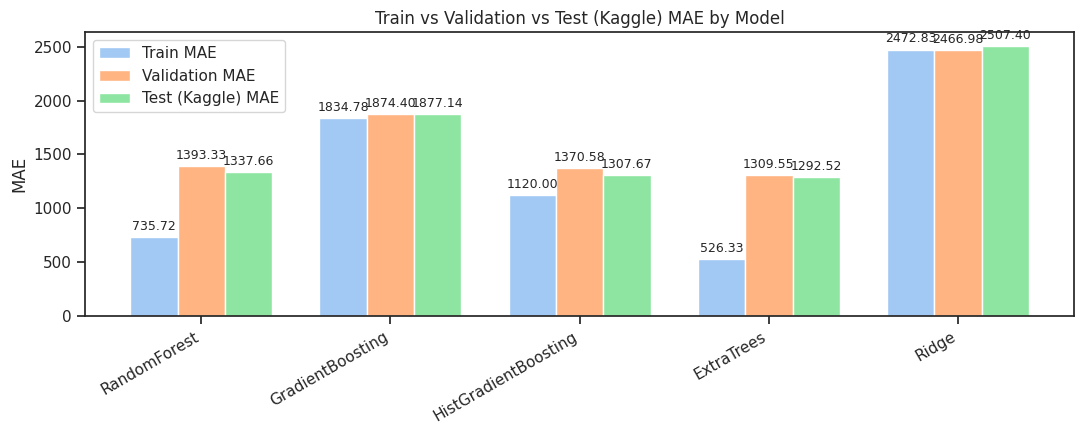

In [338]:
models = ["RandomForest", "GradientBoosting", "HistGradientBoosting", "ExtraTrees", "Ridge"]

train_mae = [735.7248, 1834.7802, 1119.9991, 526.3264, 2472.8323]
val_mae   = [1393.3256, 1874.3986, 1370.5807, 1309.5492, 2466.9797]
test_mae  = [1337.66016, 1877.13922, 1307.67233, 1292.52405, 2507.40004]

x = np.arange(len(models))
width = 0.25

# ---- Plot ----
fig, ax = plt.subplots(figsize=(11, 4.5))

bars_train = ax.bar(x - width, train_mae, width, label="Train MAE")
bars_val   = ax.bar(x,         val_mae,   width, label="Validation MAE")
bars_test  = ax.bar(x + width, test_mae,  width, label="Test (Kaggle) MAE")

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha="right")
ax.set_ylabel("MAE")
ax.set_title("Train vs Validation vs Test (Kaggle) MAE by Model")
ax.legend()

add_bar_labels(ax, bars_train)
add_bar_labels(ax, bars_val)
add_bar_labels(ax, bars_test)

fig.tight_layout()
plt.show()

Since the validation results are coherent with test results we can assume that leakage was minimal. Histogram Gradient Boosting probably ahs the best bias-variance tradeoff.

## **5.6 Blend Predictions 0.2ET+0.4RF+0.4HGB**

- A blended **ensemble model** was constructed using the three best-performing individual models:
  - Random Forest Regressor
  - Histogram Gradient Boosting
  - Extra Trees Regressor

- The ensemble pipeline retrieves the previously trained models from memory, where they were stored after generating the individual Kaggle submissions.

- Each model independently generates predictions on the test dataset using the same preprocessing artifacts learned during training.

- The final ensemble prediction is computed as a **weighted average** of the individual model predictions.
  - In a more formal setting, ensemble weights would typically be derived from:
    - Inverse validation error weighting, or
    - R²-based weighting schemes
  - Due to time constraints, weights were instead adjusted empirically to maximize Kaggle performance.

- This pragmatic weighting strategy resulted in the **best overall Kaggle score**, achieving a Mean Absolute Error of **1262.58**, outperforming all individual models.


In [339]:

def ensemble_ET_RF_HGB_from_registry(
    registry,
    cat_cols,
    int_cols,
    float_cols,
    drop_cols,
    weights=(0.2, 0.4, 0.4),  # (ET, RF, HGB)
    test_csv="test.csv",
    id_col="carID",
    target_col="price",
    out_csv="submission_weighted_ET_RF_HGB.csv",
    ensemble_name="Ensemble_ET_RF_HGB",
    store_test_pred=True,
):
    wanted = ["ExtraTrees", "RandomForest", "HistGradientBoosting"]
    required = {"estimator", "ohe", "artifacts", "train_feature_cols", "apply_outliers"}

    # check if models exist in registry, otherwisee raise a error
    for name in wanted:
        if name not in registry:
            raise KeyError(f"'{name}' missing from registry. Available: {list(registry.keys())}")
        missing = required - set(registry[name].keys())
        if missing:
            raise KeyError(
                f"registry['{name}'] missing {missing}. "
                f"Keys: {list(registry[name].keys())}. "
                f"Make sure you're using the fitted registry from train_predict_save_all."
            )

    # if weights dont sum to 1, rescale them
    w_et, w_rf, w_hgb = weights
    s = w_et + w_rf + w_hgb
    w_et, w_rf, w_hgb = w_et / s, w_rf / s, w_hgb / s
    wmap = {"ExtraTrees": w_et, "RandomForest": w_rf, "HistGradientBoosting": w_hgb}

    # load + clean test
    test_df = pd.read_csv(test_csv)
    X_test = clean_df(test_df.copy(), valid_models, cat_cols)
    X_test = X_test.drop(columns=list(drop_cols), errors="ignore")

    if id_col not in test_df.columns:
        raise KeyError(
            f"ID column '{id_col}' not found in test.csv. Columns: {test_df.columns.tolist()}"
        )
    test_ids = test_df[id_col].copy()

    preds = {}

    # predict from each fitted member DO NOT REFIT
    for name in wanted:
        b = registry[name]
        est = b["estimator"]
        ohe = b["ohe"]
        artifacts = b["artifacts"]
        feat_cols = b["train_feature_cols"]
        apply_outliers = b["apply_outliers"]

        # filter column lists to only columns that exist in THIS df
        int_f   = [c for c in int_cols   if c in X_test.columns]
        float_f = [c for c in float_cols if c in X_test.columns]
        cat_f   = [c for c in cat_cols   if c in X_test.columns]

        X_test_proc, _ = preprocess_for_search(
            X_test,
            int_cols=int_f,
            float_cols=float_f,
            cat_cols=cat_f,
            ohe=ohe,  # already fitted
            apply_outliers=apply_outliers,
            fit=False,
            fill_values=artifacts.get("fill_values"),
            outlier_info=artifacts.get("outlier_info"),
        )

        X_test_proc = X_test_proc.reindex(columns=feat_cols, fill_value=0)

        preds[name] = est.predict(X_test_proc)
        print(f"[OK] {name} fetched+predicted")

    # ensemble prediction
    ensemble_pred = (
        wmap["ExtraTrees"] * preds["ExtraTrees"]
        + wmap["RandomForest"] * preds["RandomForest"]
        + wmap["HistGradientBoosting"] * preds["HistGradientBoosting"]
    )

    # save Kaggle submission
    submission = pd.DataFrame({id_col: test_ids, target_col: ensemble_pred})
    submission.to_csv(out_csv, index=False)
    print(f"[ENSEMBLE OK] Saved {out_csv}")

    # append the trained ensemble to the registry for direct use in the interface
    registry[ensemble_name] = {
        "type": "weighted_average",
        "members": wmap,
        "member_names": wanted,
        "estimator": None,
        "ohe": None,
        "artifacts": None,
        "train_feature_cols": None,
        "apply_outliers": None,
        "submission_file": out_csv,
        "notes": f"Weighted avg: {w_et:.3f} ET + {w_rf:.3f} RF + {w_hgb:.3f} HGB",
    }
    if store_test_pred:
        registry[ensemble_name]["test_pred"] = ensemble_pred

    return submission

sub = ensemble_ET_RF_HGB_from_registry(
    registry=FITTED_REGISTRY,
    cat_cols=cat_cols,
    int_cols=int_cols,
    float_cols=float_cols,
    drop_cols=drop_cols,
    weights=(0.2, 0.4, 0.4),
    test_csv="test.csv",
    out_csv="submission_weighted_ET_RF_HGB.csv",
)


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] ExtraTrees fetched+predicted


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] RandomForest fetched+predicted


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.



[OK] HistGradientBoosting fetched+predicted
[ENSEMBLE OK] Saved submission_weighted_ET_RF_HGB.csv


In [340]:
FITTED_REGISTRY

{'RandomForest': {'estimator': RandomForestRegressor(max_depth=30, max_features=0.5, max_samples=0.7,
                        n_estimators=200, n_jobs=-1, random_state=1907),
  'ohe': OneHotEncoder(drop='first', handle_unknown='ignore'),
  'artifacts': {'fill_values': {'float': {'mileage': np.float64(23352.797091695324),
     'tax': np.float64(121.25927623394078),
     'mpg': np.float64(55.204844209618095),
     'engineSize': np.float64(1.6717694778459276),
     'mileage_per_year': np.float64(7638.887505594436),
     'power_efficiency': np.float64(0.033724381500460726)},
    'int': {'year': np.float64(3.0), 'previousOwners': np.float64(2.0)}},
   'outlier_info': {'year': {'log': True,
     'clip': True,
     'lower': 0.0,
     'upper': 2.772588722239781,
     'q_low': 0.001,
     'q_high': 0.999,
     'mad_z': 3.5,
     'skew_raw': 2.065871416934958,
     'upper_only': False},
    'previousOwners': {'log': False,
     'clip': False,
     'lower': None,
     'upper': None,
     'q_low':

## **5.7 Conclusion**

- Excluding the final blended ensemble, **Histogram Gradient Boosting** was identified as the most performant individual model.
  - This conclusion is based on its **validation MAE** and a particularly favorable **bias–variance trade-off**.
  - The negligible gap between training and validation performance indicates strong generalization.

- Overall results can be considered **solid**, as the team placed within the **upper quartile of the Kaggle leaderboard**.
  - While this indicates competitive performance, it also highlights clear opportunities for improvement.

- A major limitation of the project was **time management and pipeline instability**.
  - The original pipeline was abandoned approximately **two days before the deadline**.
  - This decision followed an attempt to implement cross-validated model selection **without relying on scikit-learn’s built-in Pipeline abstractions**.
  - The resulting codebase became excessively complex, difficult to reason about, and likely prone to data leakage.
  - Debugging proved impractical, as reflected by the large and fragmented GitHub commit history.

- As a consequence, the team reverted to a **simplified workflow** based on a **fixed hold-out validation split** derived from a previous version of the project.
  - This approach had to be stabilized and finalized within a **very limited time window (<48 hours)**.

- The **data cleaning and exploratory analysis** stages were functional but limited in depth.
  - Feature selection, in particular, proved problematic and produced results that were ultimately not used in the final models.

- Despite these constraints, the **final modeling workflow appears to be largely leakage-safe** and produced competitive results.
  - Validation and Kaggle scores were coherent and closely aligned, suggesting that the hold-out strategy did not lead to severe under-testing.

- Several improvements were identified but not implemented due to time constraints:
  - More advanced NaN imputation strategies (e.g. **KNN imputation**)
  - The inclusion of a **feature scaler**, which would have been straightforward to add
  - Alternative categorical encodings:
    - Exclusive reliance on **One-Hot Encoding** resulted in very high RAM usage
    - Sparse binary encodings likely degraded the performance of **Ridge Regression**
    - Frequency encoding and target-agnostic categorical encodings were considered but not implemented

- While cross-validation would have been the preferred evaluation strategy and was likely expected for the project, the consistency between validation and Kaggle performance suggests that the chosen approach remained reasonably reliable.

- Given additional time, the project would benefit from:
  - Rebuilding the original pipeline around **scikit-learn Pipelines and column transformers**
  - Enabling **proper cross-validation without leakage**
  - Simplifying the overall codebase while improving robustness and reproducibility

- Ultimately, the project reflects a pragmatic trade-off between methodological idealism and delivery under time pressure:
  - *“Finished is better than perfect.”*


# **6. INTERFACE (OPEN ENDED)**

We built a very plain and bare-bones interface for predicting the price of a single car.

The interface generates independent price predictions using several trained models and combines them through a blended ensemble based on weighted averaging.

In addition to individual and ensemble predictions, a model disagreement metric is reported to capture variability across models.

The system is exposed through a Gradio-based interactive dashboard, allowing real-time exploration of model outputs.

In [341]:
def _to_nan_if_empty(x):
    if x is None:
        return np.nan
    if isinstance(x, str) and x.strip() == "":
        return np.nan
    return x

def _as_float_or_nan(x):
    x = _to_nan_if_empty(x)
    if pd.isna(x):
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

def _as_int_or_nan(x):
    x = _to_nan_if_empty(x)
    if pd.isna(x):
        return np.nan
    try:
        return int(x)
    except Exception:
        return np.nan


BASE5 = ["Ridge", "RandomForest", "ExtraTrees", "GradientBoosting", "HistGradientBoosting"]
ENSEMBLE_NAME = "Ensemble_ET_RF_HGB"
WANTED_MODELS = BASE5 + [ENSEMBLE_NAME]

missing = [m for m in WANTED_MODELS if m not in FITTED_REGISTRY]
if missing:
    raise KeyError(
        f"FITTED_REGISTRY is missing models: {missing}. "
        f"Available: {list(FITTED_REGISTRY.keys())}"
    )


def _predict_one_from_bundle(bundle, input_clean):
    est = bundle["estimator"]
    ohe = bundle["ohe"]
    artifacts = bundle["artifacts"]
    apply_outliers = bundle["apply_outliers"]
    feat_cols = bundle["train_feature_cols"]

    int_f   = [c for c in int_cols   if c in input_clean.columns]
    float_f = [c for c in float_cols if c in input_clean.columns]
    cat_f   = [c for c in cat_cols   if c in input_clean.columns]

    X_proc, _ = preprocess_for_search(
        input_clean,
        int_cols=int_f,
        float_cols=float_f,
        cat_cols=cat_f,
        ohe=ohe,
        apply_outliers=apply_outliers,
        fit=False,
        fill_values=artifacts.get("fill_values"),
        outlier_info=artifacts.get("outlier_info"),
    )

    X_proc = X_proc.reindex(columns=feat_cols, fill_value=0)
    return float(est.predict(X_proc)[0])


def predict_single_car_all_models(
    brand,
    model_name,
    year,
    mileage,
    fuelType,
    transmission,
    engineSize,
    tax=None,
    mpg=None,
    paintQuality=None,
    previousOwners=None
):

    if model_name is None or (isinstance(model_name, str) and model_name.strip() == ""):
        models_for_brand = sorted(valid_models.get(brand, []))
        model_name = models_for_brand[0] if models_for_brand else "UNKNOWN"

    input_df = pd.DataFrame([{
        "carID": -1,
        "Brand": brand,
        "model": model_name,
        "year": _as_int_or_nan(year),
        "mileage": _as_float_or_nan(mileage),
        "fuelType": fuelType,
        "transmission": transmission,
        "engineSize": _as_float_or_nan(engineSize),
        "tax": _as_float_or_nan(tax),
        "mpg": _as_float_or_nan(mpg),
        "paintQuality%": _as_float_or_nan(paintQuality),
        "previousOwners": _as_int_or_nan(previousOwners),
        "hasDamage": 0
    }])

    input_clean = clean_df(input_df, valid_models, cat_cols)

    preds = {}

    for name in BASE5:
        preds[name] = _predict_one_from_bundle(FITTED_REGISTRY[name], input_clean)

    ens = FITTED_REGISTRY[ENSEMBLE_NAME]
    if ens.get("type") == "weighted_average":
        members = ens["members"]
        member_names = ens["member_names"]
        preds[ENSEMBLE_NAME] = float(sum(members[m] * preds[m] for m in member_names))
    else:
        preds[ENSEMBLE_NAME] = float("nan")

    # disagreement only on base 5
    preds["DisagreementStd(5)"] = float(np.std([preds[m] for m in BASE5]))

    return preds


brand_list = sorted(valid_models.keys())

def update_models(brand):
    models = sorted(valid_models.get(brand, []))
    # if brand has no models, keep dropdown empty
    if not models:
        return gr.update(choices=[], value=None)
    return gr.update(choices=models, value=models[0])

def ui_predict(
    brand, model_name, year, mileage, fuel,
    transmission, engine, tax, mpg, paint_q, prev_owners
):
    res = predict_single_car_all_models(
        brand=brand,
        model_name=model_name,
        year=year,
        mileage=mileage,
        fuelType=fuel,
        transmission=transmission,
        engineSize=engine,
        tax=tax,
        mpg=mpg,
        paintQuality=paint_q,
        previousOwners=prev_owners
    )

    fig = go.Figure(data=[go.Bar(x=WANTED_MODELS, y=[res[m] for m in WANTED_MODELS])])
    fig.update_layout(
        title="Cars4You — Price Predictions (£)",
        yaxis_title="Predicted price",
        showlegend=False
    )

    return (
        round(res["Ridge"], 0),
        round(res["RandomForest"], 0),
        round(res["ExtraTrees"], 0),
        round(res["GradientBoosting"], 0),
        round(res["HistGradientBoosting"], 0),
        round(res["Ensemble_ET_RF_HGB"], 0),
        round(res["DisagreementStd(5)"], 0),
        fig
    )


with gr.Blocks(title="Cars4You — Car Price Prediction Dashboard (6 models)") as demo:
    gr.Markdown("Cars4You — Car Price Prediction Dashboard")

    with gr.Row():
        brand_dd = gr.Dropdown(
            choices=brand_list,
            value=brand_list[0] if brand_list else None,
            label="Brand"
        )
        init_models = sorted(valid_models.get(brand_list[0], [])) if brand_list else []
        model_dd = gr.Dropdown(
            choices=init_models,
            value=init_models[0] if init_models else None,
            label="Model"
        )

    with gr.Row():
        year = gr.Slider(1990, 2024, step=1, value=2018, label="Year")
        mileage = gr.Number(value=60000, label="Mileage (km)")
        engine = gr.Number(value=2.0, label="Engine size (L)")

    with gr.Row():
        fuel = gr.Dropdown(
            ["PETROL", "DIESEL", "HYBRID", "ELECTRIC"],
            value="DIESEL",
            label="Fuel type"
        )
        transmission = gr.Dropdown(
            ["MANUAL", "AUTOMATIC"],
            value="MANUAL",
            label="Transmission"
        )

    with gr.Row():
        tax = gr.Number(value=None, label="Tax (optional)")
        mpg = gr.Number(value=None, label="MPG (optional)")
        paint_q = gr.Number(value=None, label="Paint quality % (optional)")
        prev_owners = gr.Number(value=None, label="Previous owners (optional)")

    predict_btn = gr.Button("Predict", variant="primary")

    gr.Markdown("### Outputs")
    with gr.Row():
        out_ridge = gr.Number(label="Ridge (£)")
        out_rf = gr.Number(label="RandomForest (£)")
        out_et = gr.Number(label="ExtraTrees (£)")
        out_gb = gr.Number(label="GradientBoosting (£)")
        out_hgb = gr.Number(label="HistGradientBoosting (£)")
        out_ens = gr.Number(label="Ensemble (£)")

    with gr.Row():
        out_std = gr.Number(label="Disagreement std (base 5)")

    plot_out = gr.Plot()

    brand_dd.change(fn=update_models, inputs=brand_dd, outputs=model_dd)

    predict_btn.click(
        fn=ui_predict,
        inputs=[
            brand_dd, model_dd, year, mileage, fuel,
            transmission, engine, tax, mpg, paint_q, prev_owners
        ],
        outputs=[
            out_ridge, out_rf, out_et, out_gb, out_hgb,
            out_ens, out_std, plot_out
        ]
    )

demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c7aa853bc675296069.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:921: UserWarning:

pandas.DataFrame with sparse colu

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c7aa853bc675296069.gradio.live
